# E-commerce Funnel and Customer Behaviour Decision Analysis

**End-to-end analysis of 20.7 million user events** from a cosmetics online store (Oct 2019 - Feb 2020).
This notebook constructs a full purchase funnel, introduces a novel **three-path purchase classification**
(Immediate / Delayed / Direct), and performs temporal, customer, and product-level analysis.

**Dataset:** [Kaggle - E-commerce Events History in Cosmetics Shop](https://www.kaggle.com/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop/data)

---


In [1]:
# -- Import Libraries --
# Core: numpy, pandas | Viz: matplotlib, plotly | Utils: datetime, os

import numpy as np 
import pandas as pd 
from IPython.display import display, Markdown, Latex 
import plotly.express as px 
import matplotlib.pyplot as plt 
import datetime
import os 

for dirname, _, filenames in os.walk('/Users/monupaswan/Project'):
    for filename in filenames:
        print(os.path.join(dirname,filename))

/Users/monupaswan/Project/2020-Jan.csv
/Users/monupaswan/Project/E-commerce Funnel and Decision Analysis.ipynb
/Users/monupaswan/Project/2019-Dec.csv
/Users/monupaswan/Project/2020-Feb.csv
/Users/monupaswan/Project/2019-Nov.csv
/Users/monupaswan/Project/2019-Oct.csv
/Users/monupaswan/Project/.ipynb_checkpoints/E-commerce Funnel and Decision Analysis-checkpoint.ipynb


## 1. Data Loading & Exploration

Load 5 monthly CSV files (Oct 2019 - Feb 2020), concatenate into a single DataFrame, and inspect the schema.


In [2]:
# Load 5 monthly CSV files (Oct 2019 - Feb 2020)
# Oct alone has 4,102,283 rows x 9 columns

df_1910 = pd.read_csv('/Users/monupaswan/Project/2019-Oct.csv')
df_1911 = pd.read_csv('/Users/monupaswan/Project/2019-Nov.csv')
df_1912 = pd.read_csv('/Users/monupaswan/Project/2019-Dec.csv')
df_2001 = pd.read_csv('/Users/monupaswan/Project/2020-Jan.csv')
df_2002 = pd.read_csv('/Users/monupaswan/Project/2020-Feb.csv')
print(df_1910.shape)

(4102283, 9)


In [3]:
# Add month label to each DataFrame, then concatenate into one 20.7M-row DataFrame

df_1910['event_month'] = '2019-10'
df_1911['event_month'] = '2019-11'
df_1912['event_month'] = '2019-12'
df_2001['event_month'] = '2020-01'
df_2002['event_month'] = '2020-02'

df_all = pd.concat([df_1910,df_1911,df_1912,df_2001,df_2002])
df_all.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_month
0,2019-10-01 00:00:00 UTC,cart,5773203,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10
1,2019-10-01 00:00:03 UTC,cart,5773353,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10
2,2019-10-01 00:00:07 UTC,cart,5881589,2151191071051219817,NaN,lovely,13.48,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,2019-10
3,2019-10-01 00:00:07 UTC,cart,5723490,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10
4,2019-10-01 00:00:15 UTC,cart,5881449,1487580013522845895,NaN,lovely,0.56,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,2019-10


### Null Value Analysis

- `category_code` is **98% null** (unusable) -> use `category_id` instead
- `brand` is **42% null**
- `user_session` has only **4,598 nulls** (dropped)


In [4]:
# Inspect the combined DataFrame - 20,692,840 rows, 10 columns, ~1.7 GB

df_all.info()

<class 'pandas.DataFrame'>
Index: 20692840 entries, 0 to 4156681
Data columns (total 10 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        int64  
 8   user_session   str    
 9   event_month    str    
dtypes: float64(1), int64(3), str(6)
memory usage: 1.7 GB


In [5]:
# Null analysis: category_code 98% null, brand 42% null, user_session 4,598 null

df_all.isnull().sum()

event_time              0
event_type              0
product_id              0
category_id             0
category_code    20339246
brand             8757117
price                   0
user_id                 0
user_session         4598
event_month             0
dtype: int64

In [6]:
# Inspect rows with null user_session (these will be dropped)

nan_session = df_all[df_all['user_session'].isna()]
nan_session.sort_values(by='event_time')

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_month
22936,2019-10-01 07:39:05 UTC,cart,5727536,1487580004882580302,NaN,NaN,2.70,555532580,NaN,2019-10
22975,2019-10-01 07:39:29 UTC,cart,5699811,1487580004882580302,NaN,NaN,2.70,555532580,NaN,2019-10
53702,2019-10-01 11:29:29 UTC,cart,5873252,1487580013615120588,NaN,NaN,4.29,401104846,NaN,2019-10
61974,2019-10-01 12:34:50 UTC,cart,5861726,1487580008313521133,NaN,NaN,7.14,555627944,NaN,2019-10
65533,2019-10-01 13:06:35 UTC,cart,5665855,1487580013900333275,NaN,irisk,2.06,555638076,NaN,2019-10
...,...,...,...,...,...,...,...,...,...,...
4095264,2020-02-29 15:18:19 UTC,remove_from_cart,5838504,1487580011534745720,NaN,levrana,3.17,589287299,NaN,2020-02
4138006,2020-02-29 20:08:57 UTC,cart,5905553,1487580009177546772,NaN,runail,44.44,622041829,NaN,2020-02
4149101,2020-02-29 21:38:25 UTC,cart,4591,1487580007483048900,NaN,runail,5.95,622065819,NaN,2020-02
4150213,2020-02-29 21:50:16 UTC,cart,5817925,1487580008145748965,NaN,NaN,7.54,622068594,NaN,2020-02


In [7]:
# Distribution of null-session events: 82% cart, 17% remove, 1% view

nan_session['event_type'].value_counts()

event_type
cart                3776
remove_from_cart     791
view                  31
Name: count, dtype: int64

### Event Type Distribution

After cleaning: **20,688,242 events**. Views dominate (46.7%), cart (27.9%), remove (19.2%), purchase (6.2%).


In [8]:
# Drop 4,598 rows with null user_session -> 20,688,242 rows remaining

df_all = df_all.dropna(subset='user_session')
df_all

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_month
0,2019-10-01 00:00:00 UTC,cart,5773203,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10
1,2019-10-01 00:00:03 UTC,cart,5773353,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10
2,2019-10-01 00:00:07 UTC,cart,5881589,2151191071051219817,NaN,lovely,13.48,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,2019-10
3,2019-10-01 00:00:07 UTC,cart,5723490,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885,2019-10
4,2019-10-01 00:00:15 UTC,cart,5881449,1487580013522845895,NaN,lovely,0.56,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9,2019-10
...,...,...,...,...,...,...,...,...,...,...
4156677,2020-02-29 23:59:32 UTC,view,5885416,1487580005092295511,NaN,grattol,6.27,622082947,fb29909b-6ef5-4662-b4ee-288e73e5dc10,2020-02
4156678,2020-02-29 23:59:39 UTC,cart,5550686,1487580008145748965,NaN,NaN,1.11,459705611,05d2add3-01f7-47ee-8364-27341673227f,2020-02
4156679,2020-02-29 23:59:45 UTC,view,5850628,1602943681873052386,NaN,grattol,5.24,622090043,ab7d349f-db5d-4790-8ab1-31e5c894459d,2020-02
4156680,2020-02-29 23:59:54 UTC,view,5716351,1487580010872045658,NaN,irisk,0.79,619841242,18af673b-7fb9-4202-a66d-5c855bc0fd2d,2020-02


In [9]:
# Count each event type: view (9.66M), cart (5.76M), remove (3.98M), purchase (1.29M)

event_types = df_all['event_type'].value_counts()
event_types

event_type
view                9657790
cart                5764557
remove_from_cart    3978888
purchase            1287007
Name: count, dtype: int64

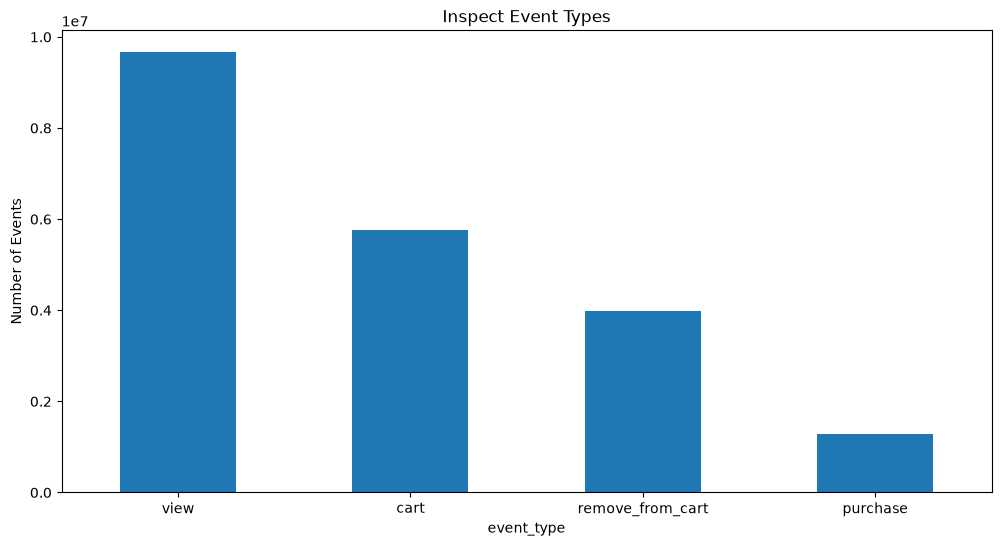

In [10]:
# Bar chart: Event Type Distribution

plt.figure(figsize=(12,6))
plt.title('Inspect Event Types')
plt.xlabel('Event')
plt.ylabel('Number of Events')
event_types.plot.bar()
plt.xticks(rotation=0)
plt.show()

In [11]:
# Convert event_time from string to datetime64[UTC] for temporal analysis

df = df_all.copy(deep=False)
df['event_time'] = pd.to_datetime(df['event_time'])

---
## 2. E-Commerce Funnel Construction

Build a **session-level pivot table** with binary flags for each event type, then compute
**nested** (sequential View->Cart->Purchase) and **non-nested** funnel metrics.


In [12]:
# Verify datetime conversion successful

df.info()

<class 'pandas.DataFrame'>
Index: 20688242 entries, 0 to 4156681
Data columns (total 10 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[us, UTC]
 1   event_type     str                
 2   product_id     int64              
 3   category_id    int64              
 4   category_code  str                
 5   brand          str                
 6   price          float64            
 7   user_id        int64              
 8   user_session   str                
 9   event_month    str                
dtypes: datetime64[us, UTC](1), float64(1), int64(3), str(5)
memory usage: 1.7 GB


### Nested Funnel (Sequential V -> C -> P)

Only counts sessions that followed the **strict sequence**: View first, then Cart, then Purchase.
- View->Cart: **18.4%** conversion, **81.6%** drop-off
- Cart->Purchase: **13.5%** conversion, **86.5%** drop-off
- Overall View->Purchase: **2.5%** effective rate


In [13]:
# -- Nested Funnel Construction --
# Pivot: one row per session, binary flags for view/cart/purchase
# Then compute sequential V->VC->VCP counts and conversion/drop-off rates

sess_flags = (
    df.pivot_table(index='user_session',
                   columns='event_type',
                   values='user_id',
                   aggfunc='size',
                   fill_value=0)
)

sess_flags['has_view'] = sess_flags.get('view',0) > 0
sess_flags['has_cart'] = sess_flags.get('cart',0) > 0
sess_flags['has_purchase'] = sess_flags.get('purchase',0) > 0

sess_flags = sess_flags[['has_view','has_cart','has_purchase']]

V = sess_flags['has_view'].sum()
VC = (sess_flags['has_view'] & sess_flags['has_cart']).sum()
VCP = (sess_flags['has_view'] & sess_flags['has_cart'] & sess_flags['has_purchase']).sum()

nested_funnel = pd.DataFrame({
    'stage':['V (View)', 'VC (View+Cart)', 'VCP (View+Cart+Purchase)'],
    'sessions': [V,VC,VCP]
})
nested_funnel['next_session'] = nested_funnel['sessions'].shift(-1)
nested_funnel['Conversion_to_next_%'] = (nested_funnel['next_session']/nested_funnel['sessions'])*100
nested_funnel['drop_off_sessions'] = nested_funnel['sessions']-nested_funnel['next_session']
nested_funnel['drop_off_rate_%'] = (nested_funnel['drop_off_sessions']/nested_funnel['sessions'])*100

nested_funnel 

,stage,sessions,next_session,Conversion_to_next_%,drop_off_sessions,drop_off_rate_%
0,V (View),4280701,788430.0,18.418245,3492271.0,81.581755
1,VC (View+Cart),788430,106526.0,13.511155,681904.0,86.488845
2,VCP (View+Cart+Purchase),106526,NaN,NaN,NaN,NaN


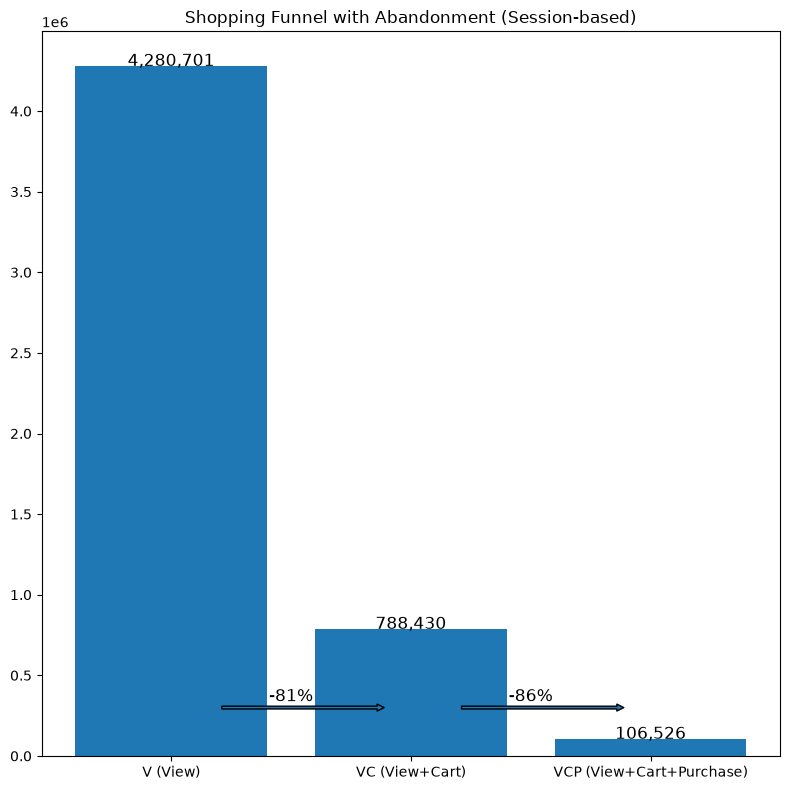

In [14]:
# Bar chart: Nested funnel with conversion % and drop-off % annotations

fig, ax = plt.subplots(figsize=(8,8))

ax.bar(list(nested_funnel['stage']),nested_funnel['sessions'])

for i in range(len(nested_funnel['sessions']-1)):
    y = nested_funnel['sessions'].iloc[i]
    ax.text(i, y+13, f'{y:,}', ha='center',fontsize=12)
    ax.annotate('',xy=(i+0.9, 300000), xytext=(i+0.2, 300000), arrowprops=dict(arrowstyle='simple'))
    if(nested_funnel['drop_off_rate_%'].iloc[i] > 1):
        ax.text(i+0.5, 340000,f'-{int(nested_funnel['drop_off_rate_%'].iloc[i])}%', ha='center',fontsize=12)

ax.set_title('Shopping Funnel with Abandonment (Session-based)')
plt.tight_layout()
plt.show()

In [15]:
# Compare non-nested (any session with event) vs nested (sequential) session counts

funnel_compare = pd.DataFrame({
    'non_nested_session' : [sess_flags['has_view'].sum(),sess_flags['has_cart'].sum(),sess_flags['has_purchase'].sum()],
    'nested_session' : [V,VC,VCP]
}, index = ['View','Cart','Purchase'])
funnel_compare

,non_nested_session,nested_session
View,4280701,4280701
Cart,985780,788430
Purchase,155617,106526


In [16]:
# Compute the difference: sessions that cart/purchase WITHOUT a prior view event

funnel_compare['diff'] = funnel_compare['non_nested_session']-funnel_compare['nested_session']
funnel_compare

,non_nested_session,nested_session,diff
View,4280701,4280701,0
Cart,985780,788430,197350
Purchase,155617,106526,49091


In [17]:
# Non-nested funnel: View 4.28M -> Cart 986K (23.0%) -> Purchase 156K (15.8%)

funnel_df = pd.DataFrame({
    'stage': ['Product View', 'Add to cart', 'Purchase'],
    'sessions': [
        sess_flags['has_view'].sum(),
        sess_flags['has_cart'].sum(),
        sess_flags['has_purchase'].sum()
    ]
})

funnel_df['next_session'] = funnel_df['sessions'].shift(-1)
funnel_df['drop_off_sessions'] = funnel_df['sessions']-funnel_df['next_session']
funnel_df['drop_off_rate_%'] = (funnel_df['drop_off_sessions']/funnel_df['sessions'])*100
funnel_df['Conversion_to_next_%'] = (funnel_df['next_session']/funnel_df['sessions'])*100

funnel_df

,stage,sessions,next_session,drop_off_sessions,drop_off_rate_%,Conversion_to_next_%
0,Product View,4280701,985780.0,3294921.0,76.971529,23.028471
1,Add to cart,985780,155617.0,830163.0,84.213821,15.786179
2,Purchase,155617,NaN,NaN,NaN,NaN


### Non-Nested vs Nested Funnel Comparison

**Key finding:** 197,350 cart sessions and 49,091 purchase sessions occurred **without a prior view event**.
These users likely arrived via external links, saved carts, or direct product URLs.


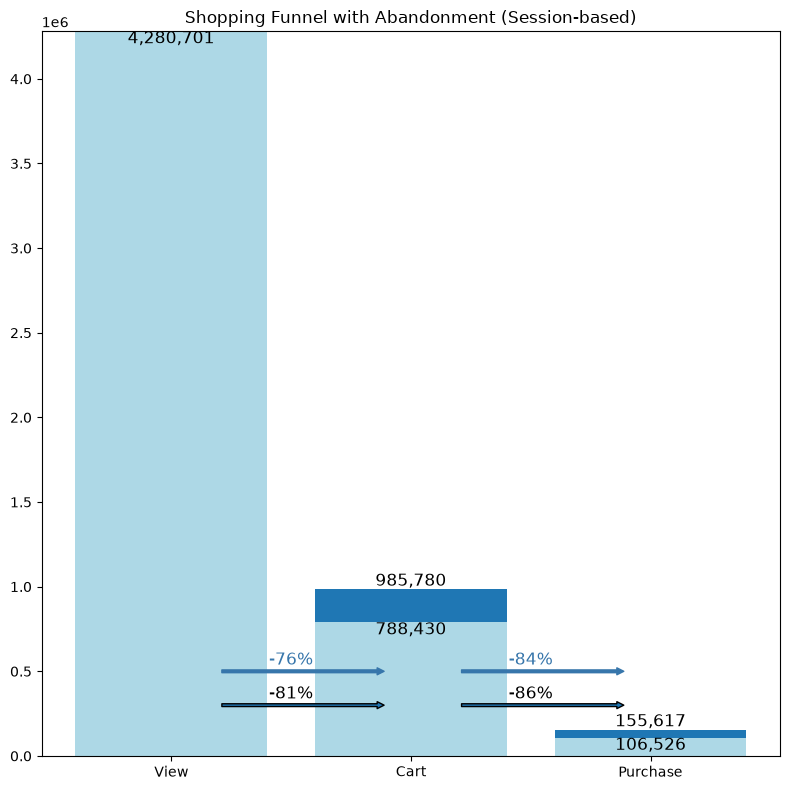

In [18]:
# Stacked bar: Nested (blue) vs non-nested (blue+light blue) funnel comparison

plt.figsize=(8,10)
sessions = ['View','Cart','Purchase']
fig, ax = plt.subplots(figsize=(8,8))

ax.bar(sessions, funnel_compare['nested_session'],color='lightblue')
ax.bar(sessions, funnel_compare['diff'], bottom=funnel_compare['nested_session'])

for i in range(len(nested_funnel['sessions']-1)):
    y = nested_funnel['sessions'].iloc[i]
    ax.text(i, y-70000, f'{y:,}',ha='center',fontsize=12)
    ax.annotate('',xy=(i+0.9,300000),xytext=(i+0.2,300000),arrowprops=dict(arrowstyle='simple'))
    if(nested_funnel['drop_off_rate_%'].iloc[i]>1):
        ax.text(i+0.5,340000,f'-{int(nested_funnel['drop_off_rate_%'].iloc[i])}%',ha='center',fontsize=12)

for i in range(len(funnel_df['sessions']-1)):
    y = funnel_df['sessions'].iloc[i]
    if(i>0):
        ax.text(i, y + 20000, f'{y:,}', ha='center', fontsize=12)
    ax.annotate("", xy=(i+0.9, 500000), xytext=(i+0.2, 500000),arrowprops=dict(arrowstyle="simple", color='#3776ab'))
    if(funnel_df['drop_off_rate_%'].iloc[i] > 1):
        ax.text(i+0.5, 540000, f'-{int(funnel_df['drop_off_rate_%'].iloc[i])}%', ha='center', fontsize=12, color='#3776ab')
ax.set_title("Shopping Funnel with Abandonment (Session-based)")
plt.tight_layout()
plt.show()

---
## 3. Purchase Path Classification

Classify every purchase session into one of three behavioral paths:
- **Immediate**: Session contains view, cart, AND purchase (same-session conversion)
- **Delayed**: No prior view/cart in the purchase session, but user had them in an **earlier session**
- **Direct**: No prior view/cart activity at all (possible bot / deep-link purchase)


In [19]:
# -- Purchase Path Classification --
# Classify each purchase session as Immediate / Delayed / Direct
# Logic: merge purchase sessions with session flags, check for prior view/cart activity

purchase_session = (
    df[df['event_type']=='purchase'].groupby(['user_session','user_id'],as_index=False)
    .agg(purchase_time=('event_time','min'))
)

purchase_session = purchase_session.merge(sess_flags,left_on='user_session',right_index=True,how='left')

purchase_session['group'] = np.where(purchase_session['has_view'] & purchase_session['has_cart'] & purchase_session['has_purchase'],'Immediate','Other')

viewcart = df[df['event_type'].isin(['view','cart'])][['user_id','event_time']].copy()

first_viewcart_time = viewcart.groupby('user_id')['event_time'].min().rename('first_viewcart_time')

purchase_session = purchase_session.merge(first_viewcart_time,on='user_id',how='left')

mask_other = purchase_session['group'].eq('Other')
mask_delayed = mask_other & purchase_session['first_viewcart_time'].notna() & (purchase_session['first_viewcart_time']<purchase_session['purchase_time'])

purchase_session.loc[mask_delayed,'group'] = 'Delayed'
purchase_session.loc[mask_other & ~mask_delayed,'group'] = 'Direct'

purchase_session


,user_session,user_id,purchase_time,has_view,has_cart,has_purchase,group,first_viewcart_time
0,000013d6-68a4-40cf-9452-6577dbfab515,405771061,2019-10-23 11:12:21+00:00,True,True,True,Immediate,2019-10-01 14:41:40+00:00
1,00008836-6d96-4580-8527-173d4e1b2889,480210325,2019-10-02 04:52:23+00:00,True,True,True,Immediate,2019-10-02 03:49:11+00:00
2,0000d04d-3516-42ea-bdb9-584e92ce619e,544281930,2020-02-15 09:11:59+00:00,True,True,True,Immediate,2019-10-15 18:15:42+00:00
3,0001981a-ee7c-4542-bf81-2cea59d963ab,556992652,2019-10-05 09:59:22+00:00,True,True,True,Immediate,2019-10-05 09:49:36+00:00
4,000277a9-30da-4bb2-b5ad-96ef24483af8,507234407,2019-12-14 09:01:26+00:00,False,True,True,Delayed,2019-10-06 14:15:13+00:00
...,...,...,...,...,...,...,...,...
155612,fffee574-c72f-03cf-4d2a-5188047c4cef,505383393,2019-12-24 07:20:04+00:00,False,False,True,Delayed,2019-10-01 06:05:58+00:00
155613,ffff78e3-1e8f-4eda-bb42-95749ab4f42e,618510291,2020-02-21 20:02:10+00:00,True,True,True,Immediate,2020-02-21 19:38:35+00:00
155614,ffff8529-58c1-4ec8-933e-77f535718061,559782512,2019-10-13 12:12:17+00:00,True,False,True,Delayed,2019-10-13 11:53:50+00:00
155615,ffff8da3-b79a-48f2-888c-117f2d1a7793,231066621,2020-02-12 08:28:55+00:00,True,True,True,Immediate,2020-01-26 10:53:09+00:00


In [20]:
# Merge total revenue per purchase session into the classified DataFrame

purchase_revenue = (
    df[df['event_type']=='purchase'].groupby('user_session',as_index=False)
    .agg(revenue=('price','sum'))
)

purchase_session = purchase_session.merge(purchase_revenue, on='user_session',how='left')
purchase_session['revenue'] = purchase_session['revenue'].fillna(0)
purchase_session


,user_session,user_id,purchase_time,has_view,has_cart,has_purchase,group,first_viewcart_time,revenue
0,000013d6-68a4-40cf-9452-6577dbfab515,405771061,2019-10-23 11:12:21+00:00,True,True,True,Immediate,2019-10-01 14:41:40+00:00,28.36
1,00008836-6d96-4580-8527-173d4e1b2889,480210325,2019-10-02 04:52:23+00:00,True,True,True,Immediate,2019-10-02 03:49:11+00:00,34.62
2,0000d04d-3516-42ea-bdb9-584e92ce619e,544281930,2020-02-15 09:11:59+00:00,True,True,True,Immediate,2019-10-15 18:15:42+00:00,6.83
3,0001981a-ee7c-4542-bf81-2cea59d963ab,556992652,2019-10-05 09:59:22+00:00,True,True,True,Immediate,2019-10-05 09:49:36+00:00,23.75
4,000277a9-30da-4bb2-b5ad-96ef24483af8,507234407,2019-12-14 09:01:26+00:00,False,True,True,Delayed,2019-10-06 14:15:13+00:00,3.55
...,...,...,...,...,...,...,...,...,...
155612,fffee574-c72f-03cf-4d2a-5188047c4cef,505383393,2019-12-24 07:20:04+00:00,False,False,True,Delayed,2019-10-01 06:05:58+00:00,31.22
155613,ffff78e3-1e8f-4eda-bb42-95749ab4f42e,618510291,2020-02-21 20:02:10+00:00,True,True,True,Immediate,2020-02-21 19:38:35+00:00,9.60
155614,ffff8529-58c1-4ec8-933e-77f535718061,559782512,2019-10-13 12:12:17+00:00,True,False,True,Delayed,2019-10-13 11:53:50+00:00,15.19
155615,ffff8da3-b79a-48f2-888c-117f2d1a7793,231066621,2020-02-12 08:28:55+00:00,True,True,True,Immediate,2020-01-26 10:53:09+00:00,9.70


In [21]:
# Purchase session share: Immediate 68.5%, Delayed 31.0%, Direct 0.5%

session_share = purchase_session['group'].value_counts(normalize=True) * 100
session_share

group
Immediate    68.453961
Delayed      31.005610
Direct        0.540429
Name: proportion, dtype: float64

In [22]:
# Revenue share by path: nearly identical to session share

revenue_share = purchase_session.groupby('group')['revenue'].sum()
revenue_share = (revenue_share/revenue_share.sum())*100
revenue_share

group
Delayed      30.990777
Direct        0.610518
Immediate    68.398705
Name: revenue, dtype: float64

### Purchase Session & Revenue Share by Path

| Path | Sessions | Share | Revenue | Share |
|------|----------|-------|---------|-------|
| Immediate | 106,526 | 68.45% | $4,341,953 | 68.40% |
| Delayed | 48,250 | 31.01% | $1,967,296 | 30.99% |
| Direct | 841 | 0.54% | $38,756 | 0.61% |


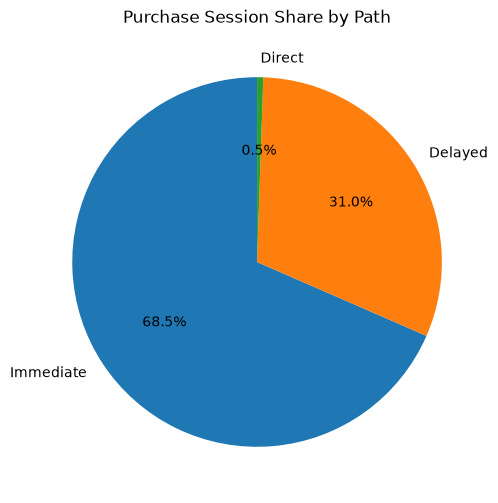

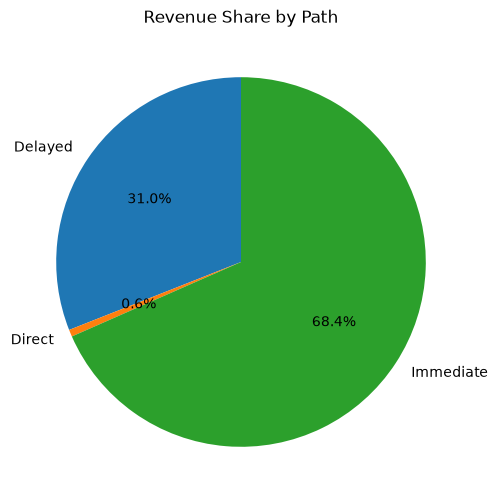

In [23]:
# Two pie charts: session share & revenue share by path

count_of_group = purchase_session['group'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(count_of_group,labels=count_of_group.index,autopct='%.1f%%',startangle=90)
plt.title('Purchase Session Share by Path')
plt.show()

rev_by_group = purchase_session.groupby('group')['revenue'].sum()

plt.figure(figsize=(6,6))
plt.pie(rev_by_group,labels=rev_by_group.index,autopct='%.1f%%',startangle=90)
plt.title('Revenue Share by Path')
plt.show()

In [24]:
# Summary table: sessions, unique users, revenue, share % by group

summary = (
    purchase_session
    .groupby('group')
    .agg(
        purchase_session=('user_session', 'nunique'),
        unique_users=('user_id', 'nunique'),
        revenue=('revenue', 'sum')
    )
    .reset_index()
)
summary['session_share_%'] = (summary['purchase_session']/summary['purchase_session'].sum()) * 100
summary['revenue_share_%'] = (summary['revenue']/summary['revenue'].sum())*100
summary.sort_values('purchase_session',ascending=False)



,group,purchase_session,unique_users,revenue,session_share_%,revenue_share_%
2,Immediate,106526,81701,4341953.14,68.453961,68.398705
0,Delayed,48250,39858,1967296.04,31.005610,30.990777
1,Direct,841,749,38755.69,0.540429,0.610518


In [25]:
# Compute per-session metrics: revenue, items, purchase time for each purchase session

p = df_all[df_all['event_type']=='purchase'].copy(deep=False)

purchase_session_metrics = (
    p.groupby(['user_session','user_id'],as_index=False)
    .agg(
        revenue_session=('price','sum'),
        items_session=('product_id','count'),
        purchase_time=('event_time','min')
    )
)

purchase_session_metrics

,user_session,user_id,revenue_session,items_session,purchase_time
0,000013d6-68a4-40cf-9452-6577dbfab515,405771061,28.36,9,2019-10-23 11:12:21 UTC
1,00008836-6d96-4580-8527-173d4e1b2889,480210325,34.62,10,2019-10-02 04:52:23 UTC
2,0000d04d-3516-42ea-bdb9-584e92ce619e,544281930,6.83,4,2020-02-15 09:11:59 UTC
3,0001981a-ee7c-4542-bf81-2cea59d963ab,556992652,23.75,6,2019-10-05 09:59:22 UTC
4,000277a9-30da-4bb2-b5ad-96ef24483af8,507234407,3.55,5,2019-12-14 09:01:26 UTC
...,...,...,...,...,...
155612,fffee574-c72f-03cf-4d2a-5188047c4cef,505383393,31.22,9,2019-12-24 07:20:04 UTC
155613,ffff78e3-1e8f-4eda-bb42-95749ab4f42e,618510291,9.60,5,2020-02-21 20:02:10 UTC
155614,ffff8529-58c1-4ec8-933e-77f535718061,559782512,15.19,6,2019-10-13 12:12:17 UTC
155615,ffff8da3-b79a-48f2-888c-117f2d1a7793,231066621,9.70,2,2020-02-12 08:28:55 UTC


In [26]:
# Verify the classified purchase_session DataFrame

purchase_session

,user_session,user_id,purchase_time,has_view,has_cart,has_purchase,group,first_viewcart_time,revenue
0,000013d6-68a4-40cf-9452-6577dbfab515,405771061,2019-10-23 11:12:21+00:00,True,True,True,Immediate,2019-10-01 14:41:40+00:00,28.36
1,00008836-6d96-4580-8527-173d4e1b2889,480210325,2019-10-02 04:52:23+00:00,True,True,True,Immediate,2019-10-02 03:49:11+00:00,34.62
2,0000d04d-3516-42ea-bdb9-584e92ce619e,544281930,2020-02-15 09:11:59+00:00,True,True,True,Immediate,2019-10-15 18:15:42+00:00,6.83
3,0001981a-ee7c-4542-bf81-2cea59d963ab,556992652,2019-10-05 09:59:22+00:00,True,True,True,Immediate,2019-10-05 09:49:36+00:00,23.75
4,000277a9-30da-4bb2-b5ad-96ef24483af8,507234407,2019-12-14 09:01:26+00:00,False,True,True,Delayed,2019-10-06 14:15:13+00:00,3.55
...,...,...,...,...,...,...,...,...,...
155612,fffee574-c72f-03cf-4d2a-5188047c4cef,505383393,2019-12-24 07:20:04+00:00,False,False,True,Delayed,2019-10-01 06:05:58+00:00,31.22
155613,ffff78e3-1e8f-4eda-bb42-95749ab4f42e,618510291,2020-02-21 20:02:10+00:00,True,True,True,Immediate,2020-02-21 19:38:35+00:00,9.60
155614,ffff8529-58c1-4ec8-933e-77f535718061,559782512,2019-10-13 12:12:17+00:00,True,False,True,Delayed,2019-10-13 11:53:50+00:00,15.19
155615,ffff8da3-b79a-48f2-888c-117f2d1a7793,231066621,2020-02-12 08:28:55+00:00,True,True,True,Immediate,2020-01-26 10:53:09+00:00,9.70


In [27]:
# Merge group label into session metrics

purchase_session_metrics = purchase_session_metrics.merge(purchase_session[['user_session','group']],on='user_session',how='left')

purchase_session_metrics


,user_session,user_id,revenue_session,items_session,purchase_time,group
0,000013d6-68a4-40cf-9452-6577dbfab515,405771061,28.36,9,2019-10-23 11:12:21 UTC,Immediate
1,00008836-6d96-4580-8527-173d4e1b2889,480210325,34.62,10,2019-10-02 04:52:23 UTC,Immediate
2,0000d04d-3516-42ea-bdb9-584e92ce619e,544281930,6.83,4,2020-02-15 09:11:59 UTC,Immediate
3,0001981a-ee7c-4542-bf81-2cea59d963ab,556992652,23.75,6,2019-10-05 09:59:22 UTC,Immediate
4,000277a9-30da-4bb2-b5ad-96ef24483af8,507234407,3.55,5,2019-12-14 09:01:26 UTC,Delayed
...,...,...,...,...,...,...
155612,fffee574-c72f-03cf-4d2a-5188047c4cef,505383393,31.22,9,2019-12-24 07:20:04 UTC,Delayed
155613,ffff78e3-1e8f-4eda-bb42-95749ab4f42e,618510291,9.60,5,2020-02-21 20:02:10 UTC,Immediate
155614,ffff8529-58c1-4ec8-933e-77f535718061,559782512,15.19,6,2019-10-13 12:12:17 UTC,Delayed
155615,ffff8da3-b79a-48f2-888c-117f2d1a7793,231066621,9.70,2,2020-02-12 08:28:55 UTC,Immediate


In [28]:
# Extended summary: AOV, avg basket size, median basket size by group

summary2 = (
    purchase_session_metrics
    .groupby('group',as_index=False)
    .agg(
        purchase_session=('user_session','nunique'),
        unique_users=('user_id','nunique'),
        revenue=('revenue_session','sum'),
        AOV=('revenue_session','mean'),
        avg_basket_size=('items_session','mean'),
        median_basket_size=('items_session','median')
    )
)
summary2['session_share_%'] = (summary2['purchase_session']/summary2['purchase_session'].sum())*100
summary2['revenue_share_%'] = (summary2['revenue']/summary2['revenue'].sum())*100

summary2.sort_values('purchase_session',ascending=False)


,group,purchase_session,unique_users,revenue,AOV,avg_basket_size,median_basket_size,session_share_%,revenue_share_%
2,Immediate,106526,81701,4341953.14,40.759562,8.253882,6.0,68.453961,68.398705
0,Delayed,48250,39858,1967296.04,40.772975,8.284373,6.0,31.005610,30.990777
1,Direct,841,749,38755.69,46.082866,9.551724,7.0,0.540429,0.610518


### Extended Metrics by Path (AOV, Basket Size, ASP)

AOV is nearly identical for Immediate ($40.76) and Delayed ($40.77), but **Direct** shows a
higher AOV ($46.08) and larger basket size (9.55 items), suggesting bulk/reseller behavior.


In [29]:
# Average selling price per item by group (nearly uniform ~$7.8-$8.0)

purchase_session_metrics['avg_selling_price_session'] = (
    purchase_session_metrics['revenue_session']/purchase_session_metrics['items_session']
)

asp_summary = (
    purchase_session_metrics.groupby('group',as_index=False)['avg_selling_price_session']
    .mean()
)
asp_summary

,group,avg_selling_price_session
0,Delayed,7.958943
1,Direct,7.755268
2,Immediate,8.007012


In [30]:
# Create event_date column for daily-level analysis

df['event_date'] = df['event_time'].dt.date

---
## 4. Temporal Analysis

Analyze daily, monthly, weekly, and hourly revenue patterns segmented by purchase path.


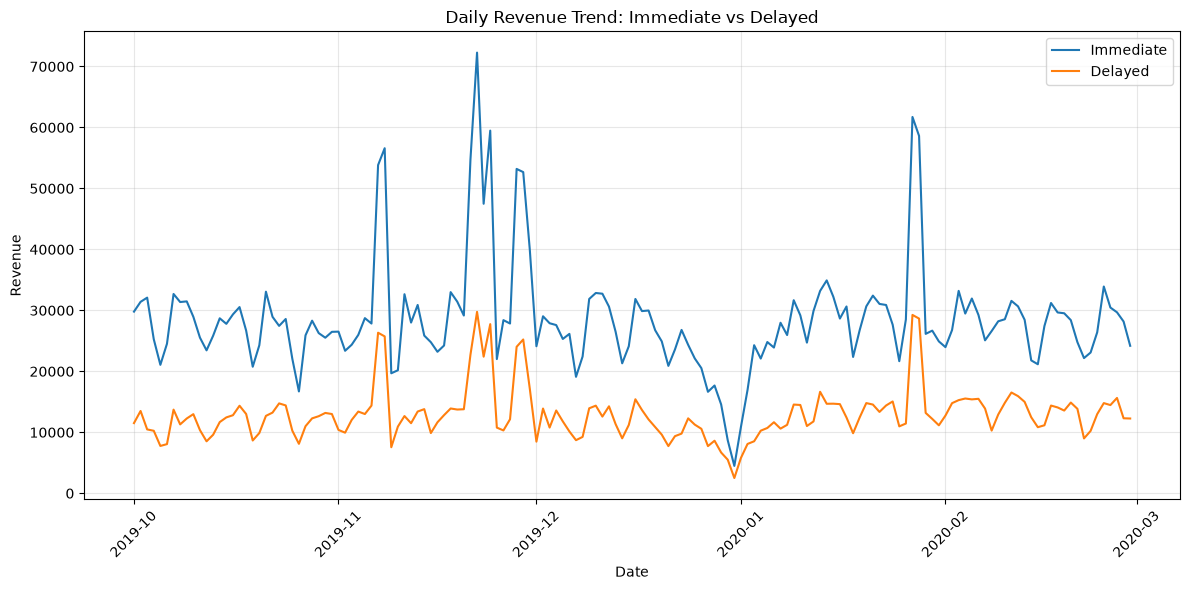

In [31]:
# Line chart: Daily revenue trend for Immediate vs Delayed (Oct 2019 - Feb 2020)

p = df[df["event_type"] == "purchase"].copy()
p["event_time"] = pd.to_datetime(p["event_time"])
p["event_date"] = p["event_time"].dt.date

p = p.merge(purchase_session[["user_session", "group"]],
            on="user_session",
            how="left")

daily_rev_by_group = (
    p.groupby(["event_date", "group"], as_index=False)
     .agg(revenue=("price", "sum"))
)

pivot_daily = (daily_rev_by_group
               .pivot(index="event_date", columns="group", values="revenue")
               .fillna(0)
               .sort_index())

plt.figure(figsize=(12,6))
plt.plot(pivot_daily.index, pivot_daily.get("Immediate", 0), label="Immediate")
plt.plot(pivot_daily.index, pivot_daily.get("Delayed", 0), label="Delayed")

plt.title("Daily Revenue Trend: Immediate vs Delayed")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [32]:
# Build monthly purchase session DataFrame with group labels

purchase_sess = (
    p.groupby(["user_session", "user_id", "event_month"], as_index=False)
     .agg(
         revenue_session=("price", "sum"),
         items_session=("product_id", "count"), 
         purchase_time=("event_time", "min")
     )
)


purchase_sess = purchase_sess.merge(
    purchase_session[["user_session", "group"]],
    on="user_session",
    how="left"
)

purchase_sess.head()

,user_session,user_id,event_month,revenue_session,items_session,purchase_time,group
0,000013d6-68a4-40cf-9452-6577dbfab515,405771061,2019-10,28.36,9,2019-10-23 11:12:21+00:00,Immediate
1,00008836-6d96-4580-8527-173d4e1b2889,480210325,2019-10,34.62,10,2019-10-02 04:52:23+00:00,Immediate
2,0000d04d-3516-42ea-bdb9-584e92ce619e,544281930,2020-02,6.83,4,2020-02-15 09:11:59+00:00,Immediate
3,0001981a-ee7c-4542-bf81-2cea59d963ab,556992652,2019-10,23.75,6,2019-10-05 09:59:22+00:00,Immediate
4,000277a9-30da-4bb2-b5ad-96ef24483af8,507234407,2019-12,3.55,5,2019-12-14 09:01:26+00:00,Delayed


In [33]:
# Monthly metrics: purchase sessions, revenue, AOV, avg basket size by group

monthly_metrics = (
    purchase_sess.groupby(['event_month','group'],as_index=False)
    .agg(
        purchase_session=('user_session','nunique'),
        revenue=('revenue_session','sum'),
        AOV=('revenue_session','mean'),
        avg_basket_size=('items_session','mean')
    )
)
monthly_metrics.head()



,event_month,group,purchase_session,revenue,AOV,avg_basket_size
0,2019-10,Delayed,8550,358677.05,41.950532,8.408421
1,2019-10,Direct,274,12074.84,44.068759,8.624088
2,2019-10,Immediate,20502,840786.54,41.009977,8.358648
3,2019-11,Delayed,11296,473013.86,41.874456,8.756285
4,2019-11,Direct,207,9790.61,47.297633,11.038647


### Monthly Revenue, AOV, and Basket Size Trends

**November 2019** (Black Friday / holiday season) is the clear peak month across all groups.
Post-holiday months show significant decline, indicating strong seasonality.


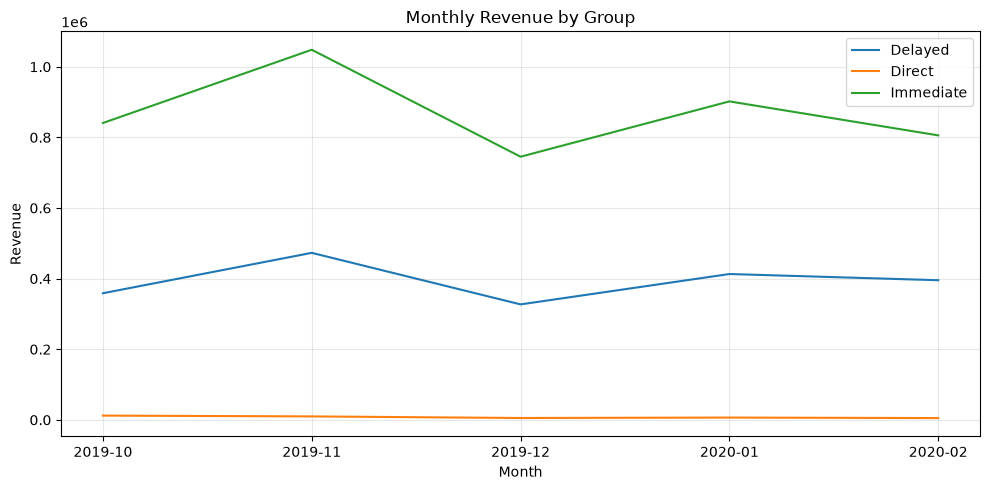

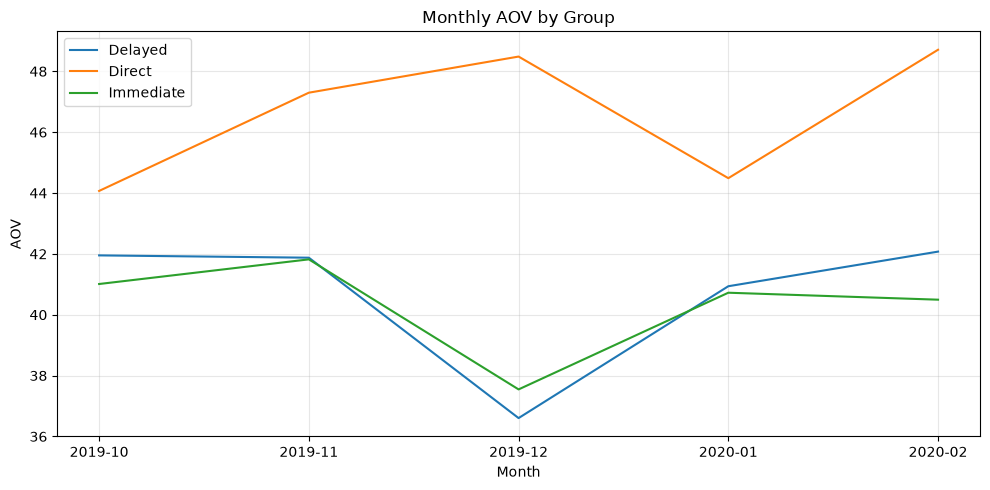

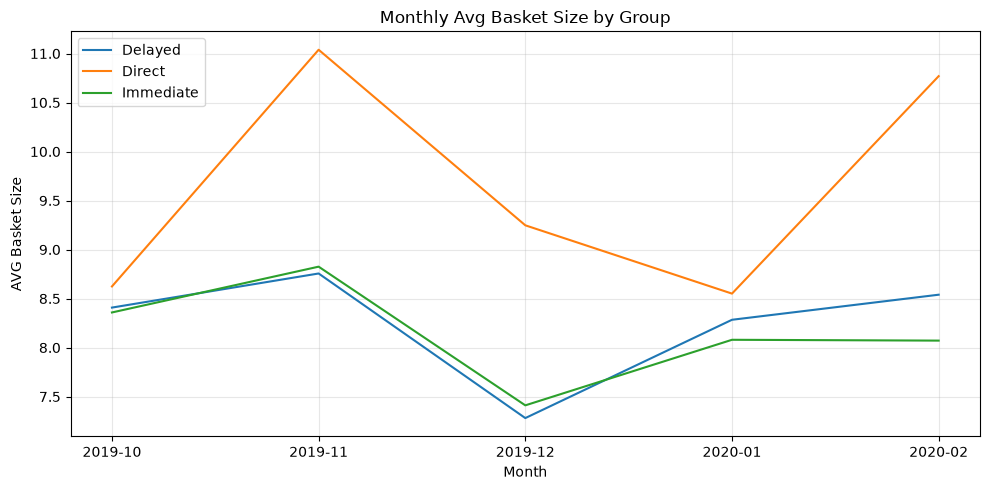

In [34]:
# Three line charts: Monthly Revenue, AOV, and Basket Size by group

def plot_metric(metric_col, title, ylabel):
    pivot = (
        monthly_metrics.pivot(index='event_month', columns='group', values=metric_col)
        .sort_index()
    )
    plt.figure(figsize=(10,5))
    for col in pivot.columns:
        plt.plot(pivot.index, pivot[col],label=col)
    plt.title(title)
    plt.xlabel('Month')
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_metric('revenue','Monthly Revenue by Group','Revenue')
plot_metric('AOV','Monthly AOV by Group','AOV')
plot_metric('avg_basket_size','Monthly Avg Basket Size by Group','AVG Basket Size')
    

In [35]:
# Classify users as New (first purchase month) or Returning

first_purchase_month = (
    purchase_sess.groupby('user_id')['event_month'].min().rename('first_purchase_month')
)
purchase_sess = purchase_sess.merge(first_purchase_month, on='user_id',how='left')
purchase_sess['cust_type'] = (purchase_sess['event_month'] == purchase_sess['first_purchase_month']).map({True:'New',False:'Returning'})




---
## 5. New vs Returning Customer Analysis

Classify purchasers as **New** (first-ever purchase month) or **Returning**, then track how the mix evolves.


In [36]:
# Verify new/returning classification

purchase_sess.head()

,user_session,user_id,event_month,revenue_session,items_session,purchase_time,group,first_purchase_month,cust_type
0,000013d6-68a4-40cf-9452-6577dbfab515,405771061,2019-10,28.36,9,2019-10-23 11:12:21+00:00,Immediate,2019-10,New
1,00008836-6d96-4580-8527-173d4e1b2889,480210325,2019-10,34.62,10,2019-10-02 04:52:23+00:00,Immediate,2019-10,New
2,0000d04d-3516-42ea-bdb9-584e92ce619e,544281930,2020-02,6.83,4,2020-02-15 09:11:59+00:00,Immediate,2019-10,Returning
3,0001981a-ee7c-4542-bf81-2cea59d963ab,556992652,2019-10,23.75,6,2019-10-05 09:59:22+00:00,Immediate,2019-10,New
4,000277a9-30da-4bb2-b5ad-96ef24483af8,507234407,2019-12,3.55,5,2019-12-14 09:01:26+00:00,Delayed,2019-10,Returning


In [37]:
# Monthly new vs returning unique users by group

monthly_new_return = (
    purchase_sess.groupby(['event_month','group','cust_type'],as_index=False)
    .agg(unique_users=('user_id','nunique'))
)
monthly_new_return.head()

,event_month,group,cust_type,unique_users
0,2019-10,Delayed,New,8030
1,2019-10,Direct,New,266
2,2019-10,Immediate,New,18544
3,2019-11,Delayed,New,8735
4,2019-11,Delayed,Returning,1792


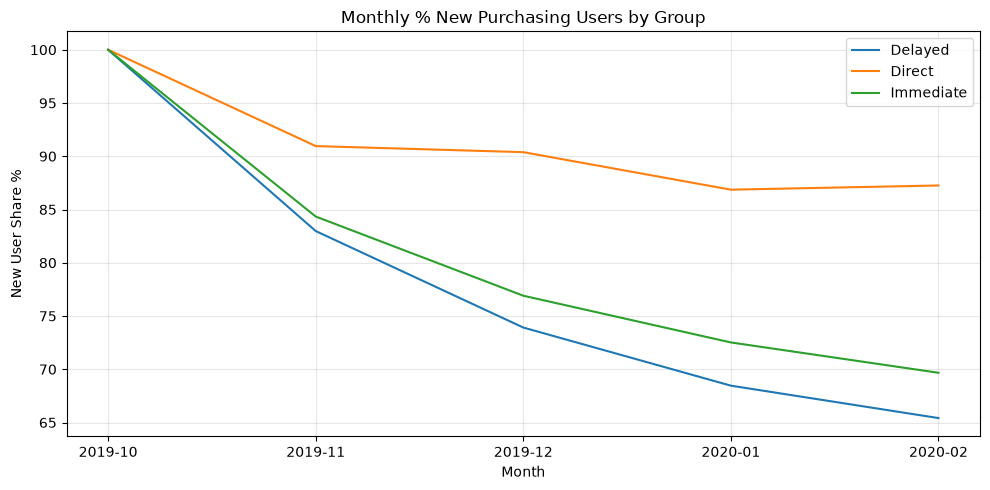

In [38]:
# Line chart: Monthly % new purchasing users by group

tmp = monthly_new_return.pivot_table(
    index=['event_month','group'], columns='cust_type', values='unique_users',fill_value=0
).reset_index()

tmp['new_share_%'] = (tmp['New']/(tmp['Returning']+tmp['New'])) * 100

pivot_new_share = tmp.pivot(index='event_month',columns='group',values='new_share_%').sort_index()
plt.figure(figsize=(10,5))
for col in pivot_new_share.columns:
    plt.plot(pivot_new_share.index,pivot_new_share[col],label=col)
plt.title('Monthly % New Purchasing Users by Group')
plt.xlabel('Month')
plt.ylabel('New User Share %')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



### New User Share Trends

October starts at **~90% new buyers**. By December, the mix shifts to **~55/45 new/returning**,
demonstrating successful conversion of first-time buyers into repeat customers.


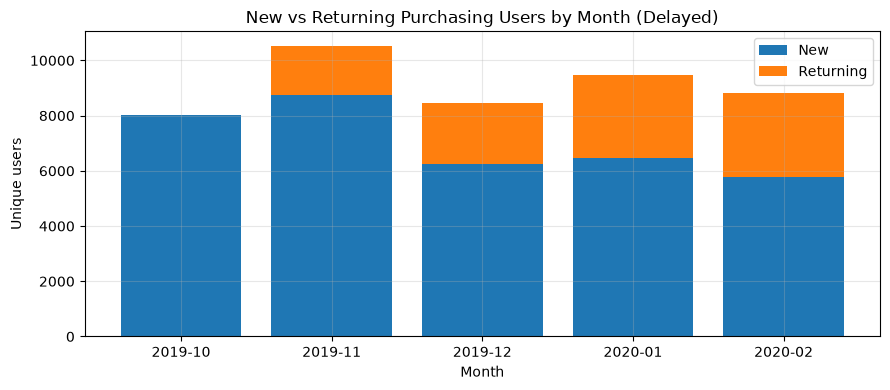

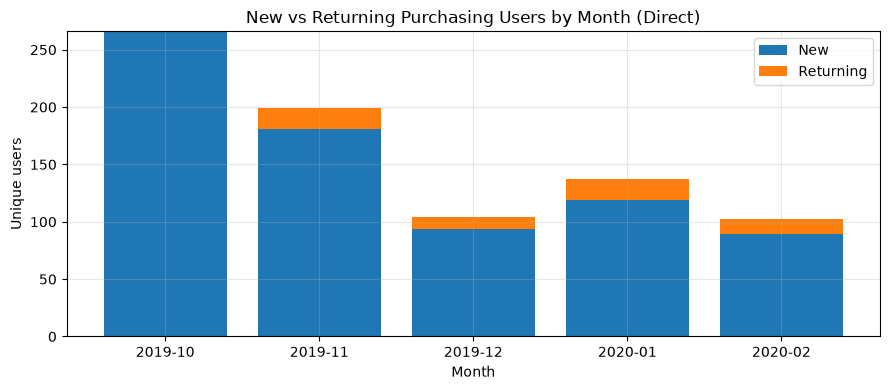

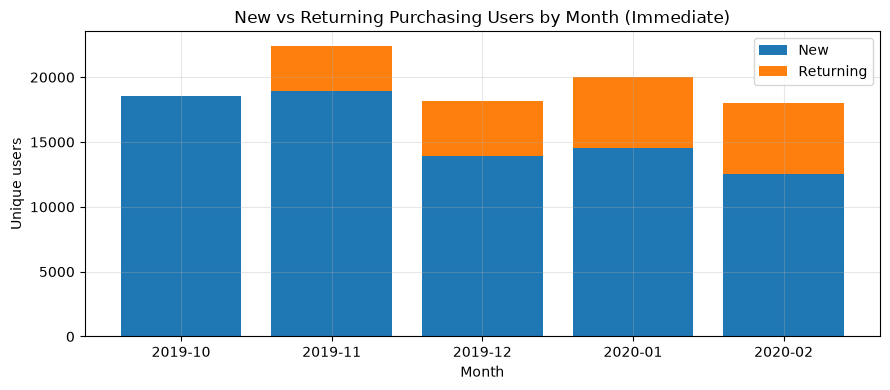

In [39]:
# Three stacked bar charts: New vs Returning by month (one per group)

tmp_sorted = tmp.copy(deep=False)
tmp_sorted['event_month'] = tmp_sorted['event_month'].astype(str)

for g in tmp_sorted['group'].unique():
    d = tmp_sorted[tmp_sorted['group']==g].set_index('event_month')

    plt.figure(figsize=(9,4))
    plt.bar(d.index,d['New'],label='New')
    plt.bar(d.index,d['Returning'],bottom=d['New'],label='Returning')

    plt.title(f"New vs Returning Purchasing Users by Month ({g})")
    plt.xlabel("Month")
    plt.ylabel("Unique users")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

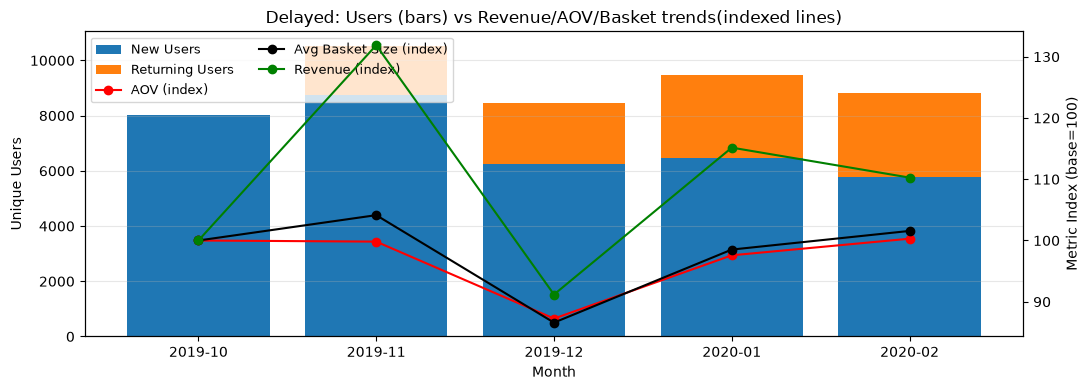

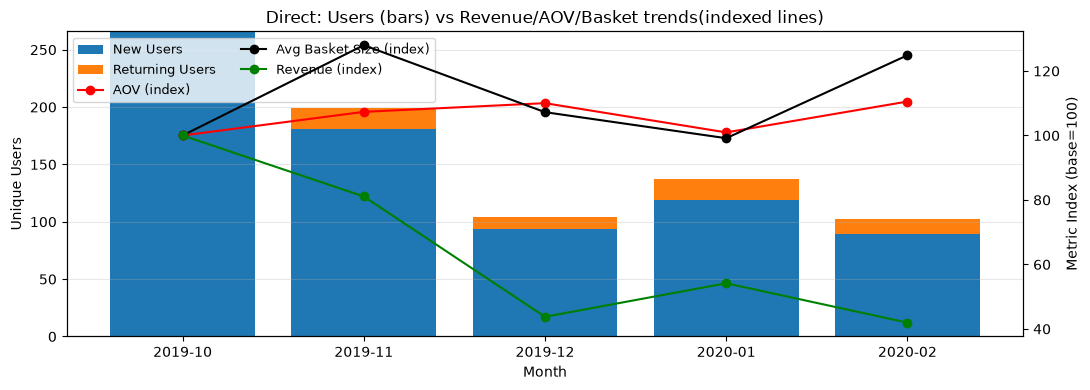

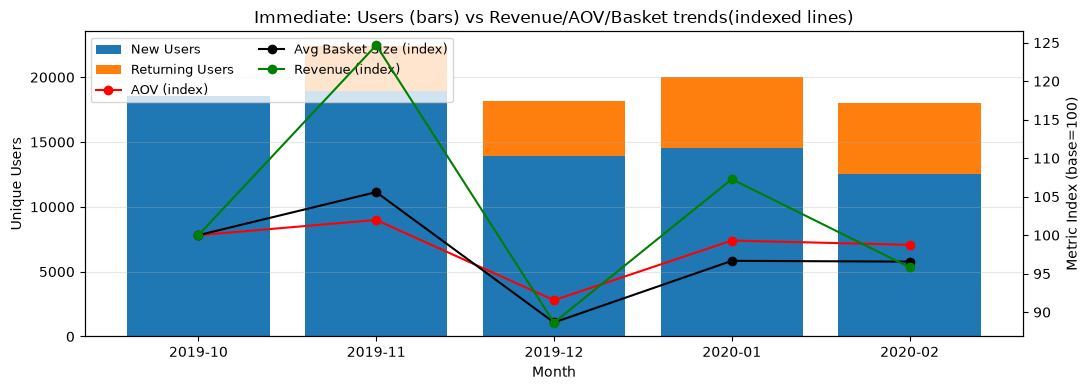

In [40]:
# Three dual-axis charts: Users (bars) + indexed Revenue/AOV/Basket (lines)

tmp2 = tmp_sorted.copy(deep=False)
tmp2['event_month'] = tmp2['event_month'].astype(str)

mm = monthly_metrics.copy(deep=False)
mm['event_month'] = mm['event_month'].astype(str)

gm = tmp2.merge(mm,on=['event_month','group'],how='left')

gm['total_users'] = gm['New']+gm['Returning']

for col in ['revenue','AOV','avg_basket_size']:
    gm[col+'_idx'] = gm.groupby('group')[col].transform(lambda s: (s/s.iloc[0])*100)

groups = gm['group'].unique()

for g in groups:
    d = gm[gm['group']==g].sort_values('event_month').copy()
    x = d['event_month'].tolist()
    
    fig, ax1 = plt.subplots(figsize=(11,4))

    ax1.bar(x,d['New'],label='New Users')
    ax1.bar(x,d['Returning'],bottom=d['New'],label='Returning Users')
    ax1.set_xlabel('Month')
    ax1.set_ylabel('Unique Users')
    ax1.grid(alpha=0.3,axis='y')

    ax2 = ax1.twinx()
    ax2.plot(x,d['AOV_idx'],marker='o',label='AOV (index)',color='red')
    ax2.plot(x,d['avg_basket_size_idx'],marker='o',label='Avg Basket Size (index)',color='black')
    ax2.plot(x,d['revenue_idx'],marker='o',label='Revenue (index)',color='g')
    ax2.set_ylabel('Metric Index (base=100)')

    ax1.set_title(f'{g}: Users (bars) vs Revenue/AOV/Basket trends(indexed lines)')

    h1,l1 = ax1.get_legend_handles_labels()
    h2,l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2,l1+l2,loc='upper left',ncol=2,fontsize=9)

    plt.tight_layout()
    plt.show()


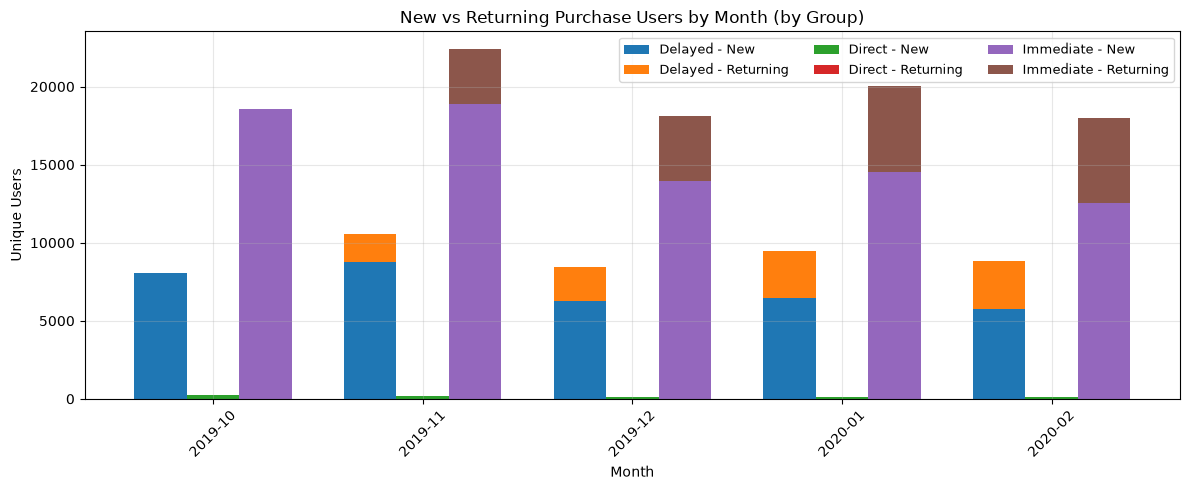

In [41]:
# Grouped bar: New vs Returning by month across all groups

d = tmp.copy(deep=False)
d['event_month'] = d['event_month'].astype(str)

months = sorted(d['event_month'].unique())
groups = list(d['group'].unique())

x = np.arange(len(months))
width = 0.25

fig, ax = plt.subplots(figsize=(12,5))

for i,g in enumerate(groups):
    dg = d[d['group']==g].set_index('event_month').reindex(months).fillna(0)
    
    ax.bar(x+i*width,dg['New'],width,label=f'{g} - New')
    ax.bar(x+i*width,dg['Returning'],width,bottom = dg['New'],label=f'{g} - Returning')

ax.set_xticks(x+width)
ax.set_xticklabels(months,rotation=45)
ax.set_xlabel('Month')
ax.set_ylabel('Unique Users')
ax.set_title('New vs Returning Purchase Users by Month (by Group)')
ax.grid(alpha=0.3)
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()



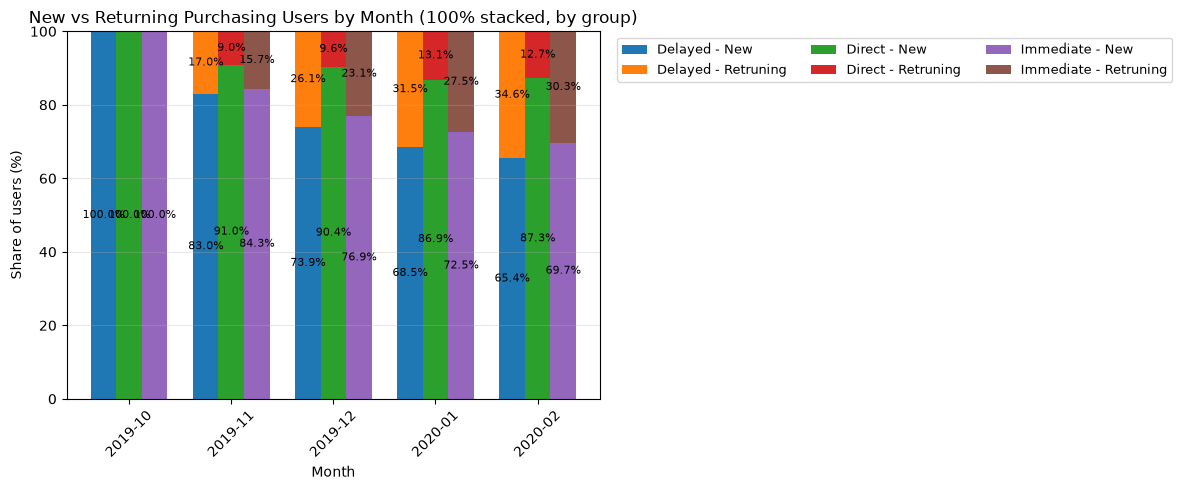

In [42]:
# 100% stacked bar: New vs Returning share % by month and group

pivot_new = (d.pivot(index='event_month',columns='group',values='New').reindex(months).fillna(0))
pivot_ret = (d.pivot(index='event_month',columns='group',values='Returning').reindex(months).fillna(0))

total = pivot_new + pivot_ret
new_pct = np.where(total.values > 0, (pivot_new.values / total.values) * 100,0)
ret_pct = np.where(total.values > 0, (pivot_ret.values / total.values) * 100,0)

fig, ax = plt.subplots(figsize=(12,5))

for i, g in enumerate(groups):
    gi = list(pivot_new.columns).index(g)

    xpos = x+i*width
    new_vals = new_pct[:, gi]
    ret_vals = ret_pct[:, gi]
    
    ax.bar(xpos,new_vals,width,label=f'{g} - New')
    ax.bar(xpos,ret_vals,width,bottom=new_vals,label=f'{g} - Retruning')

    for j in range(len(months)):
        nv = new_vals[j]
        rv = ret_vals[j]

        if nv>= 3:
            ax.text(xpos[j],nv/2,f'{nv:.1f}%',ha='center',va='center',fontsize=8)
        if rv>= 3:
            ax.text(xpos[j],nv+rv/2,f'{rv:.1f}%',ha='center',va='center',fontsize=8)

ax.set_ylim(0, 100)
ax.set_ylabel("Share of users (%)")
ax.set_xlabel("Month")
ax.set_title("New vs Returning Purchasing Users by Month (100% stacked, by group)")
ax.grid(alpha=0.3, axis="y")

ax.set_xticks(x + width)
ax.set_xticklabels(months, rotation=45)

ax.legend(ncol=3, fontsize=9, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()    


### 100% Stacked View: New vs Returning Share

This 100% stacked view makes it easy to compare the new/returning composition across groups and months.


In [43]:
# Extract weekday and hour from purchase timestamps

p['weekday'] = p['event_time'].dt.day_name()
p['hour'] = p['event_time'].dt.hour

weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
p['weekday'] = pd.Categorical(p['weekday'],categories=weekday_order,ordered=True)
p

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_month,event_date,group,weekday,hour
0,2019-10-01 00:06:35+00:00,purchase,5619862,1487580006895846315,NaN,runail,5.32,474232307,445f2b74-5e4c-427e-b7fa-6e0a28b156fe,2019-10,2019-10-01,Immediate,Tuesday,0
1,2019-10-01 00:06:35+00:00,purchase,5619866,1487580006895846315,NaN,runail,2.86,474232307,445f2b74-5e4c-427e-b7fa-6e0a28b156fe,2019-10,2019-10-01,Immediate,Tuesday,0
2,2019-10-01 00:06:35+00:00,purchase,5696184,1487580005134238553,NaN,runail,2.38,474232307,445f2b74-5e4c-427e-b7fa-6e0a28b156fe,2019-10,2019-10-01,Immediate,Tuesday,0
3,2019-10-01 00:06:35+00:00,purchase,5706784,1487580005092295511,NaN,runail,4.44,474232307,445f2b74-5e4c-427e-b7fa-6e0a28b156fe,2019-10,2019-10-01,Immediate,Tuesday,0
4,2019-10-01 00:06:35+00:00,purchase,5723503,1487580005134238553,NaN,runail,2.62,474232307,445f2b74-5e4c-427e-b7fa-6e0a28b156fe,2019-10,2019-10-01,Immediate,Tuesday,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1287002,2020-02-29 23:46:01+00:00,purchase,5896420,1487580006300255120,NaN,jessnail,49.21,620865261,64389dba-26c4-f328-6972-166a48654eaa,2020-02,2020-02-29,Delayed,Saturday,23
1287003,2020-02-29 23:54:44+00:00,purchase,5692863,1487580007910867929,NaN,yoko,7.83,548866558,199869f5-3a22-4a47-8678-7c343d09bb8e,2020-02,2020-02-29,Immediate,Saturday,23
1287004,2020-02-29 23:54:44+00:00,purchase,5802432,1487580009286598681,NaN,NaN,0.32,548866558,199869f5-3a22-4a47-8678-7c343d09bb8e,2020-02,2020-02-29,Immediate,Saturday,23
1287005,2020-02-29 23:54:44+00:00,purchase,5896788,1783999068909863670,NaN,staleks,4.75,548866558,199869f5-3a22-4a47-8678-7c343d09bb8e,2020-02,2020-02-29,Immediate,Saturday,23


---
## 6. Day-of-Week & Hour-of-Day Patterns

Extract weekday and hour from purchase timestamps to identify peak purchasing windows.


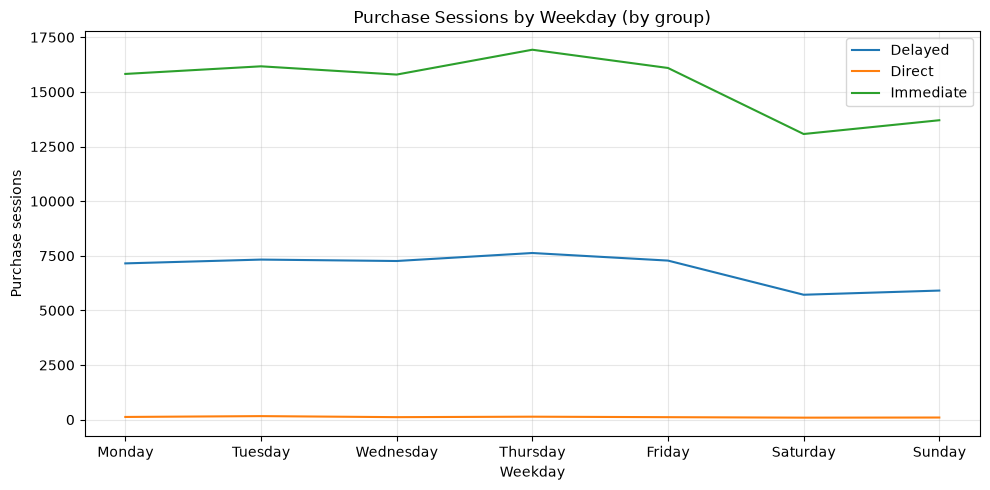

In [44]:
# Line chart: Purchase sessions by weekday (by group)

purchase_by_weekday = (
    p.groupby(['weekday','group'],as_index=False)
    .agg(purchase_session=('user_session','nunique'))
)

pivot_wd = purchase_by_weekday.pivot(index='weekday',columns='group',values='purchase_session').fillna(0).sort_index()

plt.figure(figsize=(10,5))
for col in pivot_wd.columns:
    plt.plot(pivot_wd.index.astype(str),pivot_wd[col],label=col)

plt.title("Purchase Sessions by Weekday (by group)")
plt.xlabel("Weekday")
plt.ylabel("Purchase sessions")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


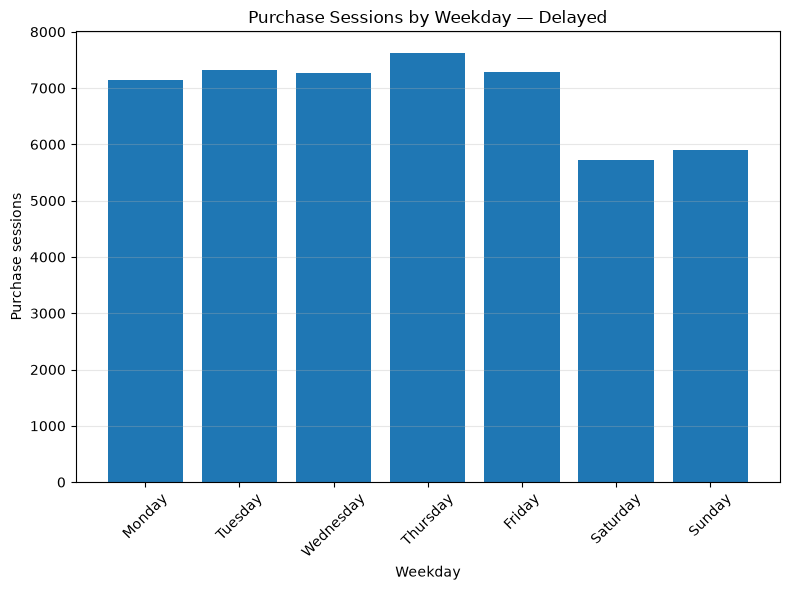

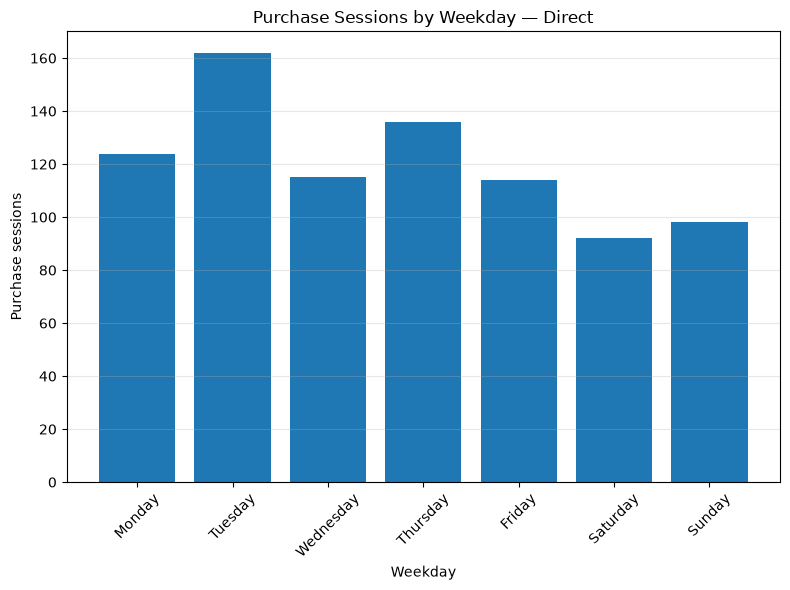

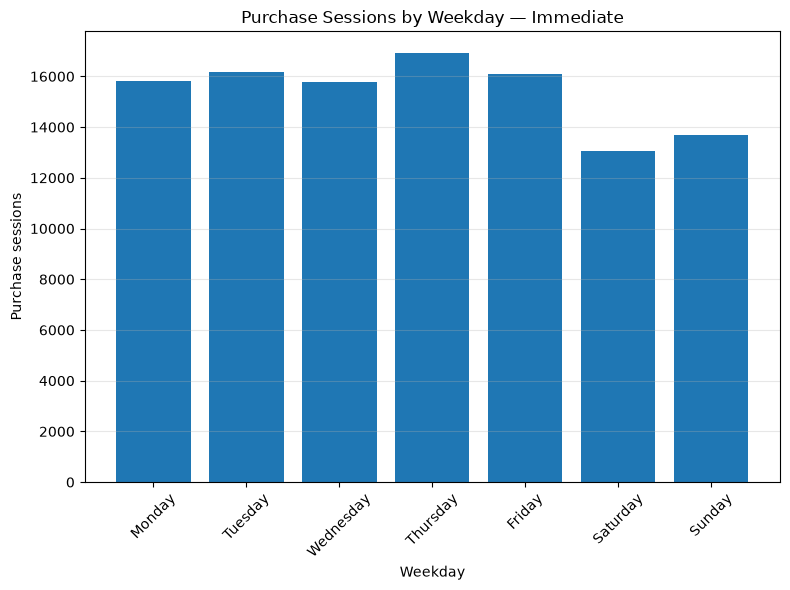

In [45]:
# Three individual bar charts: Purchase sessions by weekday (one per group)

purchase_by_weekday = (
    p.groupby(['weekday','group'],observed=True,as_index=False)
    .agg(purchase_session=('user_session','nunique'))
)

pivot_wd = purchase_by_weekday.pivot(index='weekday',columns='group',values='purchase_session').fillna(0).sort_index()
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
pivot_wd = pivot_wd.reindex(weekday_order)

for g in pivot_wd.columns:
    plt.figure(figsize=(8,6))
    plt.bar(pivot_wd.index.astype(str),pivot_wd[g])
    plt.title(f"Purchase Sessions by Weekday — {g}")
    plt.xlabel("Weekday")
    plt.ylabel("Purchase sessions")
    plt.grid(alpha=0.3, axis="y")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



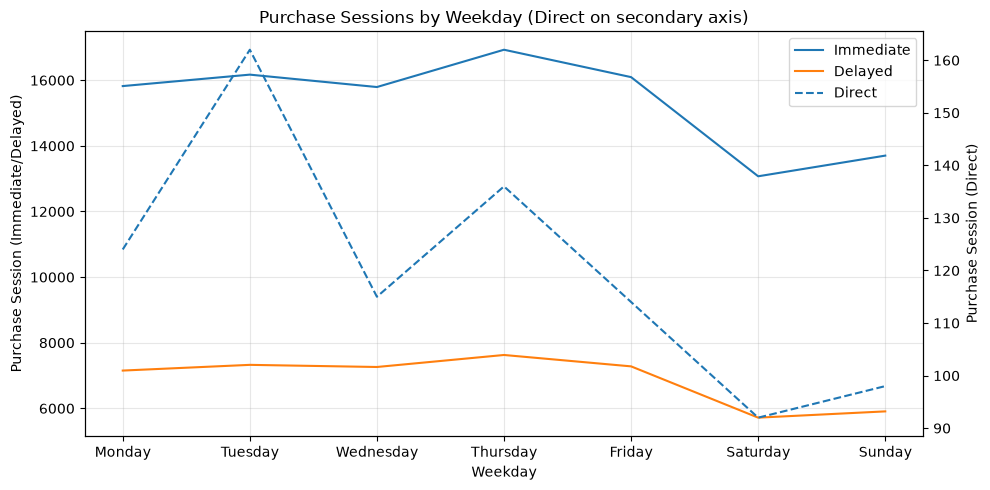

In [46]:
# Dual-axis line: Immediate/Delayed on primary, Direct (dashed) on secondary

fig, ax1 = plt.subplots(figsize=(10,5))
for g in ['Immediate','Delayed']:
    if g in pivot_wd.columns:
        ax1.plot(pivot_wd.index.astype(str),pivot_wd[g],label=g)
ax1.set_xlabel('Weekday')
ax1.set_ylabel('Purchase Session (Immediate/Delayed)')
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
if 'Direct' in pivot_wd.columns:
    ax2.plot(pivot_wd.index.astype(str), pivot_wd['Direct'],linestyle='--',label='Direct')
ax2.set_ylabel('Purchase Session (Direct)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2,labels1+labels2,loc='upper right')

plt.title("Purchase Sessions by Weekday (Direct on secondary axis)")
plt.tight_layout()
plt.show()



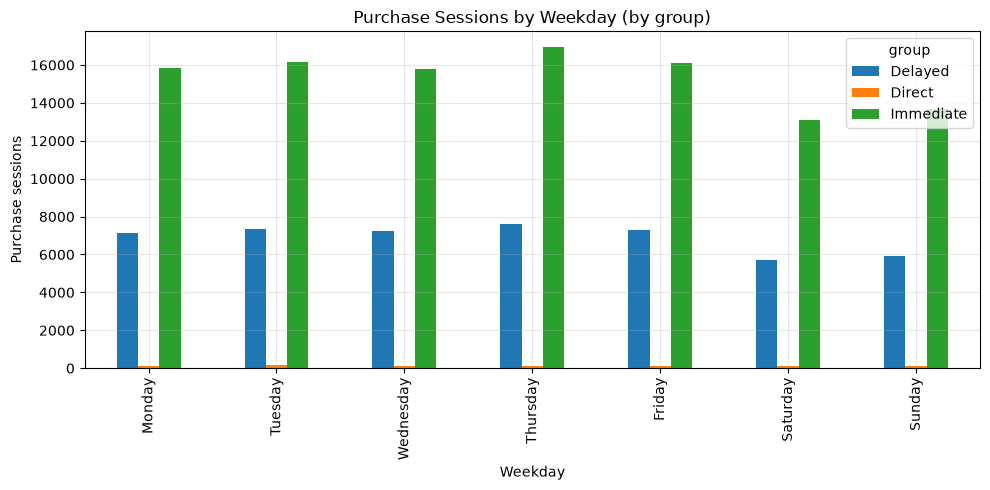

In [47]:
# Grouped bar: Purchase sessions by weekday (all 3 groups side-by-side)

pivot_wd.plot(kind='bar',figsize=(10,5))
plt.title("Purchase Sessions by Weekday (by group)")
plt.xlabel("Weekday")
plt.ylabel("Purchase sessions")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



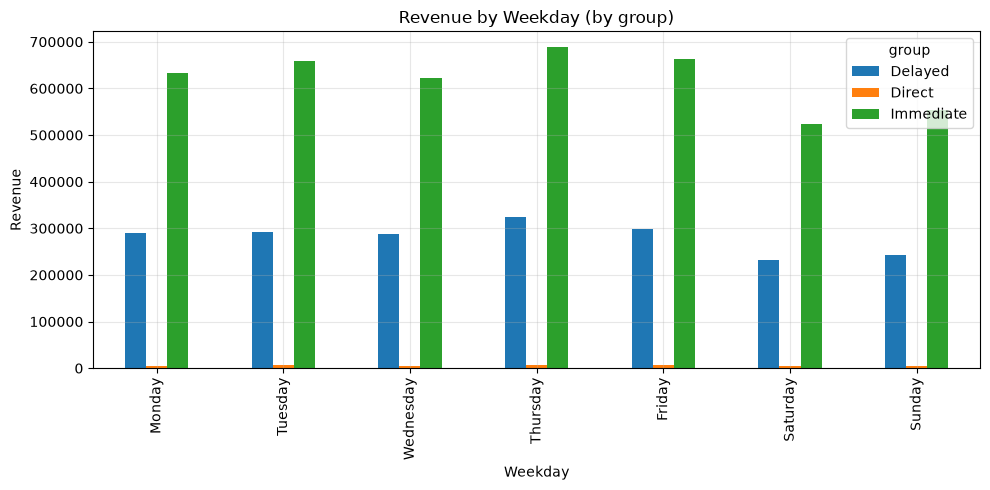

In [48]:
# Grouped bar: Revenue by weekday (all 3 groups)

revenue_by_weekday = (
    p.groupby(['weekday','group'], as_index=False)
    .agg(revenue=('price','sum'))
)
pivot_rev_wd = (revenue_by_weekday.pivot(index='weekday',columns='group',values='revenue').fillna(0).sort_index())

pivot_rev_wd.plot(kind='bar',figsize=(10,5))
plt.title("Revenue by Weekday (by group)")
plt.xlabel("Weekday")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### Weekday Revenue Patterns

**Friday** is the #1 purchase day. Sunday is the lowest.
Implication: schedule promotional campaigns for Thursday evening / Friday morning.


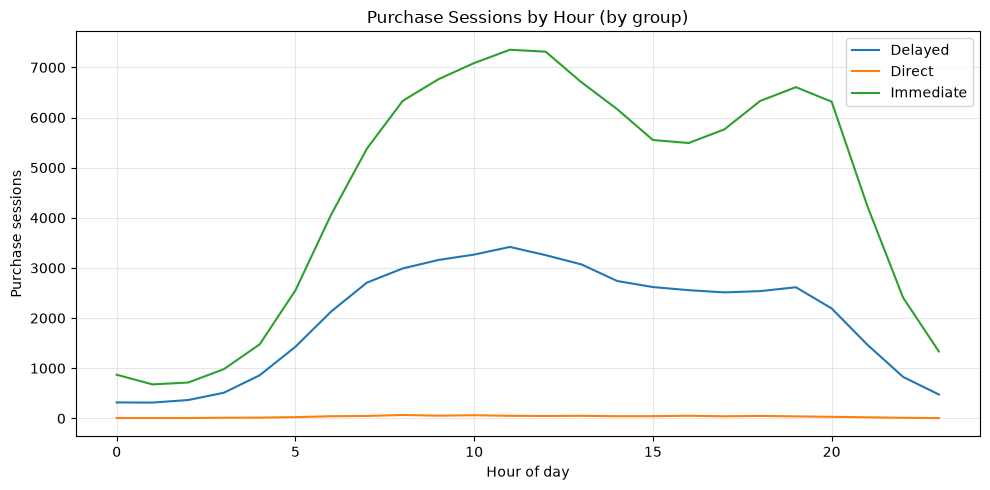

In [49]:
# Line chart: Purchase sessions by hour of day (0-23) by group

purchase_by_hour = p.groupby(['hour','group'],as_index=False).agg(purchase_session=('user_session','nunique'))
pivot_hr = (
    purchase_by_hour.pivot(index='hour',columns='group',values='purchase_session')
    .fillna(0)
    .sort_index()
)
plt.figure(figsize=(10,5))
for col in pivot_hr.columns:
    plt.plot(pivot_hr.index,pivot_hr[col],label=col)

plt.title("Purchase Sessions by Hour (by group)")
plt.xlabel("Hour of day")
plt.ylabel("Purchase sessions")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



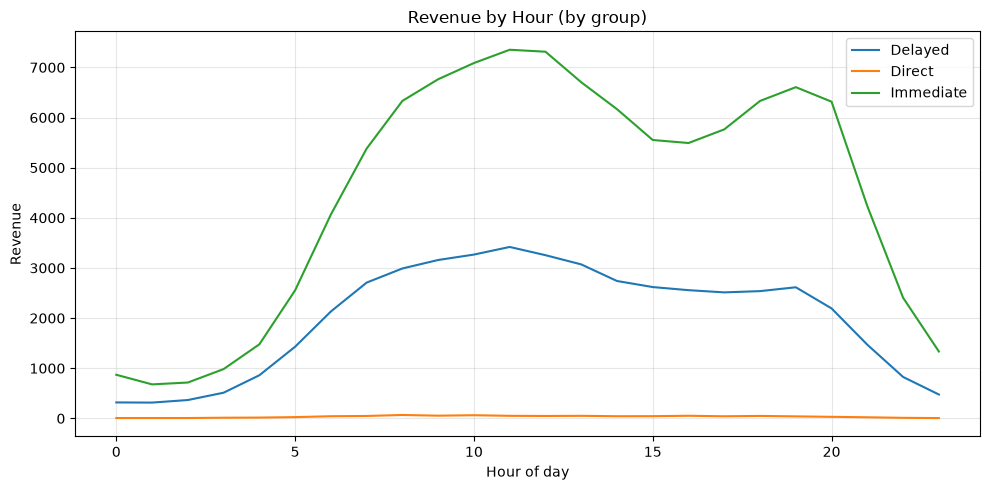

In [50]:
# Line chart: Revenue by hour of day by group

revenue_by_hour = p.groupby(['hour','group'],as_index=False).agg(revenue=('price','sum'))
pivot_rev_hr = (
    revenue_by_hour.pivot(index='hour',columns='group',values='revenue')
    .fillna(0)
    .sort_index()
)
plt.figure(figsize=(10,5))
for col in pivot_rev_hr.columns:
    plt.plot(pivot_rev_hr.index,pivot_hr[col],label=col)

plt.title("Revenue by Hour (by group)")
plt.xlabel("Hour of day")
plt.ylabel("Revenue")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



### Hourly Revenue Patterns

Revenue peaks between **5 PM - 8 PM** (post-work browsing).
Implication: allocate 60% of daily ad budget to the 4-9 PM window.


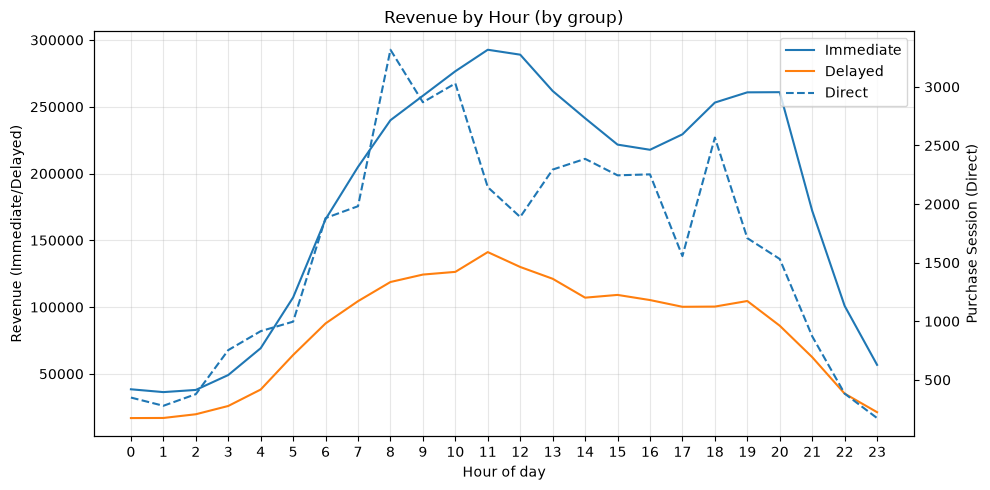

In [51]:
# Dual-axis: Revenue by hour (Immediate/Delayed primary, Direct secondary)

fig, ax1 = plt.subplots(figsize=(10,5))
for g in ['Immediate','Delayed']:
    if g in pivot_rev_hr.columns:
        ax1.plot(pivot_rev_hr.index.astype(str),pivot_rev_hr[g],label=g)
ax1.set_xlabel('Hour of day')
ax1.set_ylabel('Revenue (Immediate/Delayed)')
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
if 'Direct' in pivot_wd.columns:
    ax2.plot(pivot_rev_hr.index.astype(str), pivot_rev_hr['Direct'],linestyle='--',label='Direct')
ax2.set_ylabel('Purchase Session (Direct)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2,labels1+labels2,loc='upper right')

plt.title("Revenue by Hour (by group)") 
plt.tight_layout()
plt.show()


In [52]:
# Top 5 categories by purchase session count, per group

top_cat_by_session = (
    p.groupby(['group','category_id'], as_index=False)
    .agg(purchase_session=('user_session','nunique'))
    .sort_values(['group','purchase_session'],ascending=[True,False])
)
top5_session = top_cat_by_session.groupby('group').head(5)
top5_session

,group,category_id,purchase_session
11,Delayed,1487580005092295511,9847
13,Delayed,1487580005268456287,7867
44,Delayed,1487580006317032337,6235
137,Delayed,1487580009286598681,5845
88,Delayed,1487580007675986893,5075
470,Direct,1487580005092295511,236
472,Direct,1487580005268456287,189
492,Direct,1487580006317032337,155
561,Direct,1487580009286598681,135
524,Direct,1487580007675986893,109


---
## 7. Category & Product Analysis

Identify top-performing categories and products by both purchase sessions and revenue, segmented by purchase path.


In [53]:
# Top 5 categories by revenue, per group

top_cat_by_revenue = (
    p.groupby(['group','category_id'], as_index=False)
    .agg(revenue=('price','sum'))
    .sort_values(['group','revenue'],ascending=[True,False])
)
top5_rev = top_cat_by_revenue.groupby('group').head(5)
top5_rev

,group,category_id,revenue
11,Delayed,1487580005092295511,137693.71
43,Delayed,1487580006300255120,108668.12
13,Delayed,1487580005268456287,86539.58
300,Delayed,1602943681873052386,57182.11
44,Delayed,1487580006317032337,54999.48
470,Direct,1487580005092295511,2961.73
472,Direct,1487580005268456287,2070.81
491,Direct,1487580006300255120,1738.67
492,Direct,1487580006317032337,1526.14
480,Direct,1487580005595612013,1050.36


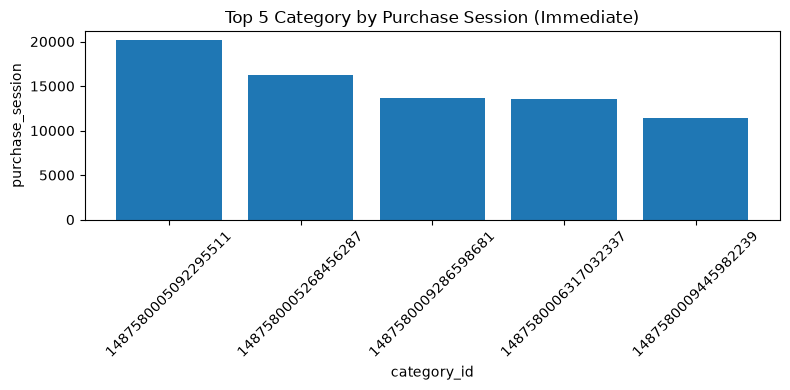

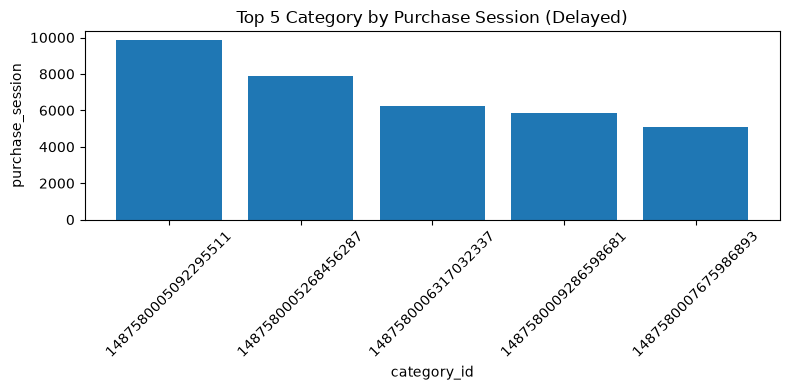

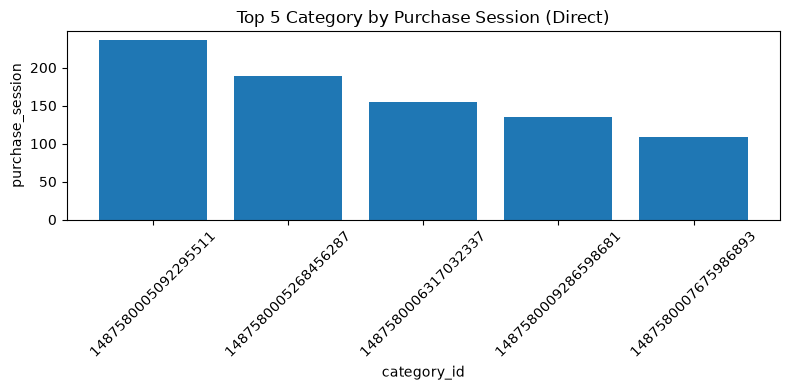

In [54]:
# Three bar charts: Top 5 categories by purchase session (one per group)

for g in p['group'].dropna().unique():
    d = top_cat_by_session[top_cat_by_session['group']==g].head(5)
    plt.figure(figsize=(8,4))
    plt.bar(d['category_id'].astype(str),d['purchase_session'])
    plt.title(f'Top 5 Category by Purchase Session ({g})')
    plt.xlabel('category_id')
    plt.ylabel('purchase_session')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



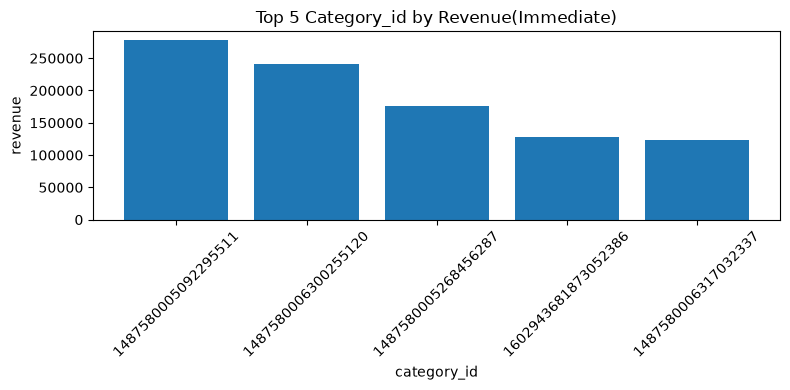

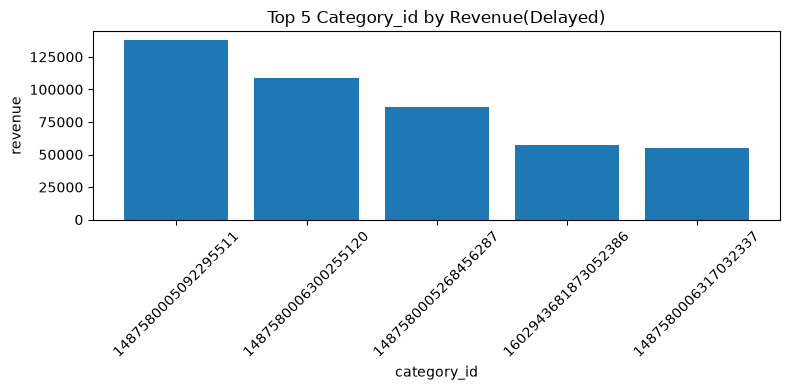

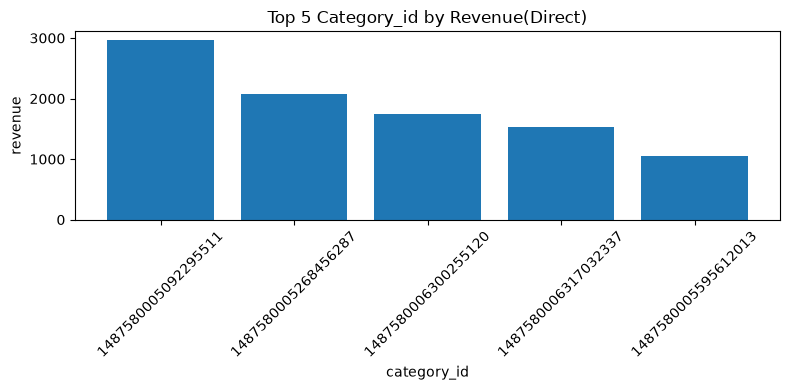

In [55]:
# Three bar charts: Top 5 categories by revenue (one per group)

for g in p["group"].dropna().unique():
    d = top_cat_by_revenue[top_cat_by_revenue["group"] == g].head(5)

    plt.figure(figsize=(8,4))
    plt.bar(d["category_id"].astype(str), d["revenue"])
    plt.title(f"Top 5 Category_id by Revenue({g})")
    plt.xlabel("category_id")
    plt.ylabel("revenue")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [56]:
# Top 5 products by purchase session (with category mapping) per group

product_cat_map = (
    p.groupby('product_id')
    .agg(
        category_id=('category_id',lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0]),
        category_code=('category_code', lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0])
    ).reset_index()
)
top_product_by_session = (
    p.groupby(['group','product_id'], as_index=False)
    .agg(purchase_session=('user_session','nunique'))
    .sort_values(['group','purchase_session'],ascending=[True,False])
)

top_product_by_session = top_product_by_session.merge(product_cat_map,on='product_id',how='left')

top5_product_session = top_product_by_session.groupby("group").head(5)
top5_product_session




,group,product_id,purchase_session,category_id,category_code
0,Delayed,5809910,2291,1602943681873052386,NaN
1,Delayed,5854897,1359,1487580009445982239,NaN
2,Delayed,5751422,1198,1487580005268456287,NaN
3,Delayed,5700037,1034,1487580009286598681,NaN
4,Delayed,5802432,1012,1487580009286598681,NaN
33367,Direct,5809910,46,1602943681873052386,NaN
33368,Direct,5854897,32,1487580009445982239,NaN
33369,Direct,5751422,28,1487580005268456287,NaN
33370,Direct,5802432,26,1487580009286598681,NaN
33371,Direct,5815662,25,1487580006317032337,NaN


### Top 5 Products by Purchase Session

Product **5809910** is the most-purchased product across all groups.
Category codes are mostly null in the dataset, so we use numeric `category_id`.


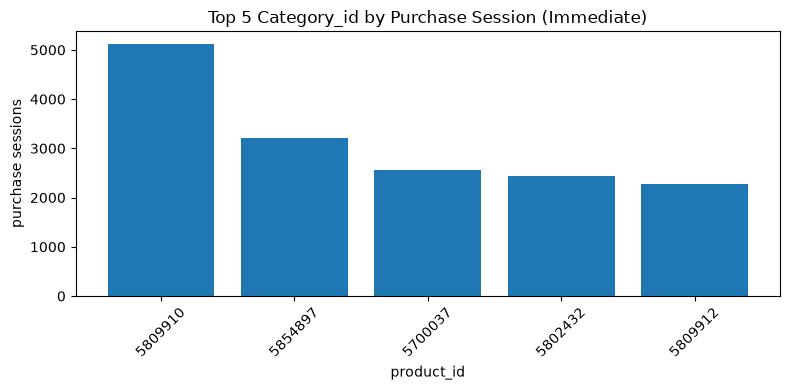

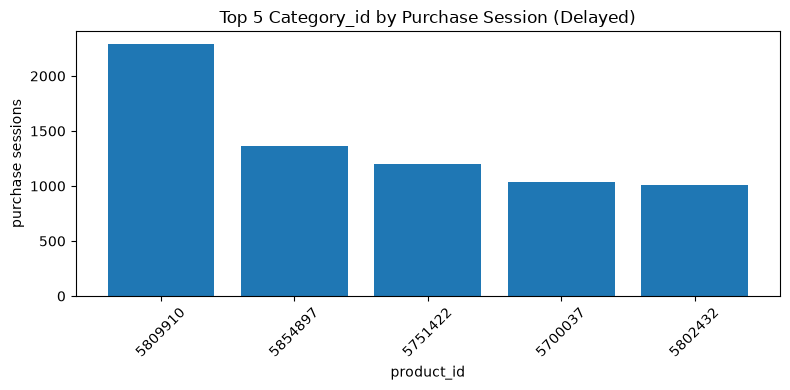

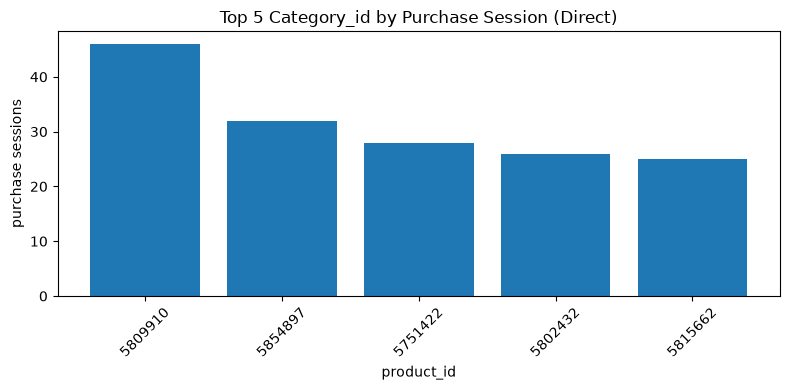

In [57]:
# Three bar charts: Top 5 products by purchase session (one per group)

for g in p['group'].dropna().unique():
    d = top5_product_session[top5_product_session['group']==g].head(5)

    plt.figure(figsize=(8,4))
    plt.bar(d['product_id'].astype(str),d['purchase_session'])
    plt.title(f'Top 5 Category_id by Purchase Session ({g})')
    plt.xlabel("product_id")
    plt.ylabel("purchase sessions")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [58]:
# Monthly items sold pivot for top 5 products per group

purch = df_all[df_all['event_type']=='purchase'].copy(deep=False)
purch['event_time'] = pd.to_datetime(purch['event_time'])
purch['event_month'] = purch['event_time'].dt.to_period('M').astype(str)

purch = purch.merge(purchase_session[['user_session','group']],on='user_session',how='left')

top_products = top5_product_session[['group','product_id']].drop_duplicates()

purch_top = purch.merge(top_products,on=['group','product_id'],how='inner')

monthly_top_products = (
    purch_top.groupby(['group','product_id','event_month'],as_index=False)
    .agg(
        items_sold=('product_id','count'),
        purchase_session=('user_session','nunique'),
        revenue=('price','sum')
    )
)
monthly_top_products.head()




/var/folders/p8/vh833xhs3ygfys_jft60j63r0000gn/T/ipykernel_34924/3735852471.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  purch['event_month'] = purch['event_time'].dt.to_period('M').astype(str)


,group,product_id,event_month,items_sold,purchase_session,revenue
0,Delayed,5700037,2019-10,187,185,74.80
1,Delayed,5700037,2019-11,229,228,88.42
2,Delayed,5700037,2019-12,189,188,75.60
3,Delayed,5700037,2020-01,239,237,95.60
4,Delayed,5700037,2020-02,197,196,78.80


### Monthly Items Sold: Top 5 Products

Track monthly sales volume for top products. **November spike** is visible for most products.


In [59]:
# Display pivot tables: Items sold per month for top 5 products

items_sold = ('quantity','sum')

for g in monthly_top_products['group'].unique():
    d = monthly_top_products[monthly_top_products['group']==g]

    pivot_items = (d.pivot(index='event_month',columns='product_id',values='items_sold')
                  .fillna(0)
                  .sort_index())
    print(f'\n=== {g}: Items Sold Per Month (Top 5 Products) ===')
    display(pivot_items)

pivot_rev = (d.pivot(index='event_month',columns='product_id',values='revenue')
            .fillna(0)
            .sort_index())




=== Delayed: Items Sold Per Month (Top 5 Products) ===


product_id,5700037,5751422,5802432,5809910,5854897
event_month,,,,,
2019-10,187,208,173,92,183
2019-11,229,319,233,636,329
2019-12,189,198,194,494,236
2020-01,239,261,210,619,320
2020-02,197,216,207,456,293



=== Direct: Items Sold Per Month (Top 5 Products) ===


product_id,5751422,5802432,5809910,5815662,5854897
event_month,,,,,
2019-10,6,7,3,6,8
2019-11,5,9,16,8,13
2019-12,3,5,7,4,1
2020-01,7,4,12,4,5
2020-02,8,1,9,3,5



=== Immediate: Items Sold Per Month (Top 5 Products) ===


product_id,5700037,5802432,5809910,5809912,5854897
event_month,,,,,
2019-10,504,460,216,231,509
2019-11,638,563,1486,618,823
2019-12,427,515,1158,428,549
2020-01,570,469,1398,654,740
2020-02,480,483,947,370,617


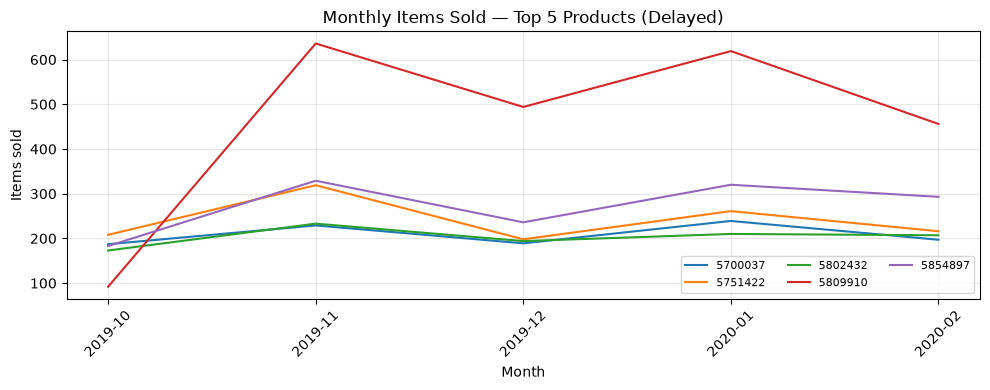

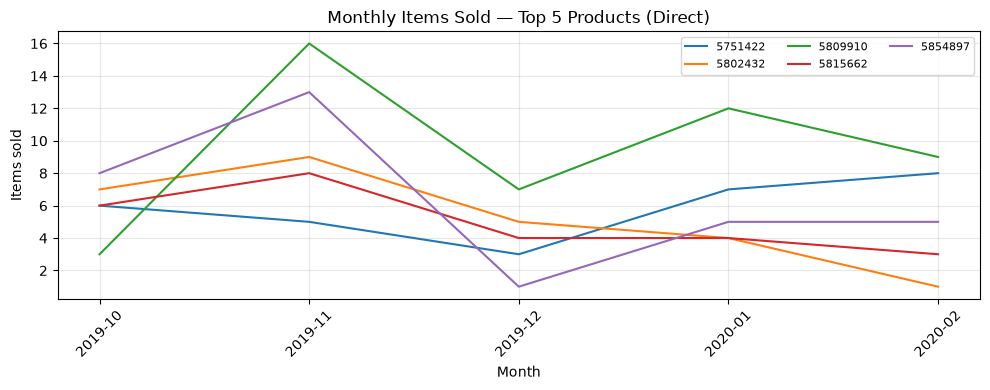

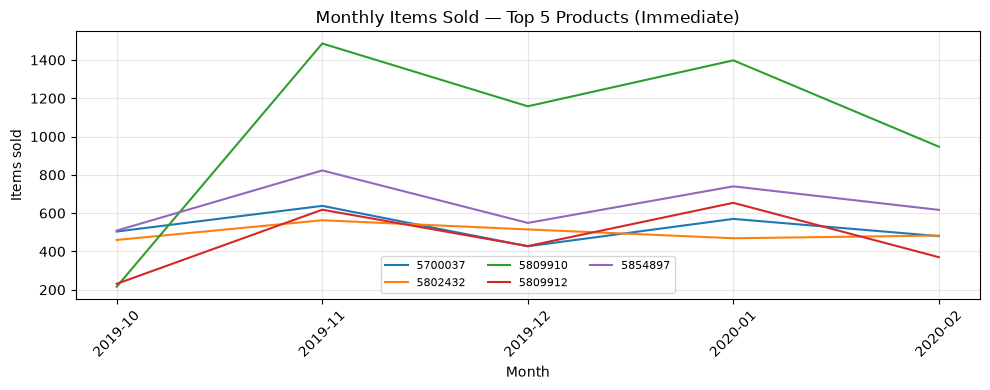

In [60]:
# Three line charts: Monthly items sold for top 5 products (one per group)

for g in monthly_top_products['group'].unique():
    d = monthly_top_products[monthly_top_products['group']==g]
    pivot_items = (d.pivot(index='event_month',columns='product_id',values='items_sold')
                  .fillna(0)
                  .sort_index())
    
    plt.figure(figsize=(10,4))
    for pid in pivot_items.columns:
        plt.plot(pivot_items.index,pivot_items[pid],label=str(pid))
    plt.title(f"Monthly Items Sold — Top 5 Products ({g})")
    plt.xlabel("Month")
    plt.ylabel("Items sold")
    plt.grid(alpha=0.3)
    plt.legend(ncol=3, fontsize=8)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [61]:
# Top 5 products by revenue per group

top_product_by_rev = (
    p.groupby(['group','product_id'],as_index=False)
    .agg(revenue=('price','sum'))
    .sort_values(['group','revenue'],ascending=[True,False])
)

top_product_by_rev = top_product_by_rev.merge(product_cat_map, on='product_id',how='left')

top5_product_rev = top_product_by_rev.groupby('group').head(5)
top5_product_rev 


,group,product_id,revenue,category_id,category_code
0,Delayed,5560754,22084.40,1487580006300255120,NaN
1,Delayed,5751422,13057.94,1487580005268456287,NaN
2,Delayed,5809910,11923.41,1602943681873052386,NaN
3,Delayed,5751383,10219.40,1487580005092295511,NaN
4,Delayed,5792800,9674.92,1487580005268456287,NaN
33367,Direct,5560754,583.32,1487580006300255120,NaN
33368,Direct,5751422,315.68,1487580005268456287,NaN
33369,Direct,5810480,293.02,1487580011283087468,NaN
33370,Direct,5861276,275.56,1487580006300255120,NaN
33371,Direct,5809910,243.98,1602943681873052386,NaN


### Top 5 Products by Revenue

Product **5560754** is the #1 revenue generator despite low volume - ASP of **~$194**,
vs ~$5 for the volume leader. This volume-vs-value disconnect is a key strategic insight.


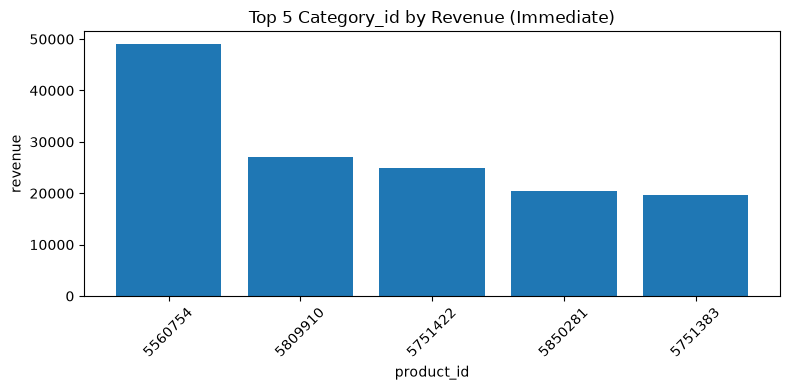

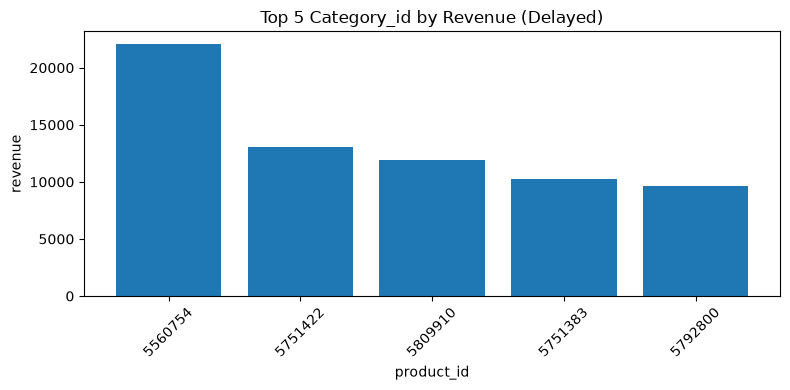

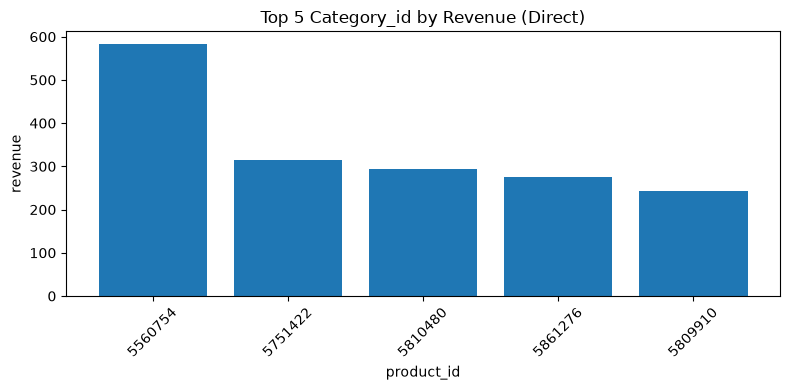

In [62]:
# Three bar charts: Top 5 products by revenue (one per group)

for g in p['group'].unique():
    d = top5_product_rev [top5_product_rev ['group']==g]
    
    plt.figure(figsize=(8,4))
    plt.bar(d['product_id'].astype(str),d['revenue'])
    plt.title(f"Top 5 Category_id by Revenue ({g})")
    plt.xlabel("product_id")
    plt.ylabel("revenue")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    

In [63]:
# Top 5 products by revenue with orders & items_sold count

top_product_by_rev = (
    p.groupby(["group", "product_id"], as_index=False)
     .agg(
         revenue=("price", "sum"),
         orders=("user_session", "nunique"), 
         items_sold=("product_id", "count"),      
     )
     .sort_values(["group", "revenue"], ascending=[True, False])
)

top_product_by_rev = top_product_by_rev.merge(product_cat_map, on="product_id", how="left")

top5_product_rev = top_product_by_rev.groupby("group").head(5)
top5_product_rev


,group,product_id,revenue,orders,items_sold,category_id,category_code
0,Delayed,5560754,22084.40,112,114,1487580006300255120,NaN
1,Delayed,5751422,13057.94,1198,1202,1487580005268456287,NaN
2,Delayed,5809910,11923.41,2291,2297,1602943681873052386,NaN
3,Delayed,5751383,10219.40,993,999,1487580005092295511,NaN
4,Delayed,5792800,9674.92,940,944,1487580005268456287,NaN
33367,Direct,5560754,583.32,3,3,1487580006300255120,NaN
33368,Direct,5751422,315.68,28,29,1487580005268456287,NaN
33369,Direct,5810480,293.02,13,13,1487580011283087468,NaN
33370,Direct,5861276,275.56,2,2,1487580006300255120,NaN
33371,Direct,5809910,243.98,46,47,1602943681873052386,NaN


### Revenue (bars) + Items Sold (lines) for Top 5 Products

The dual-axis chart reveals the **volume-value disconnect**: high-volume products do not
necessarily generate the most revenue. Promoting high-ASP products could significantly boost revenue.


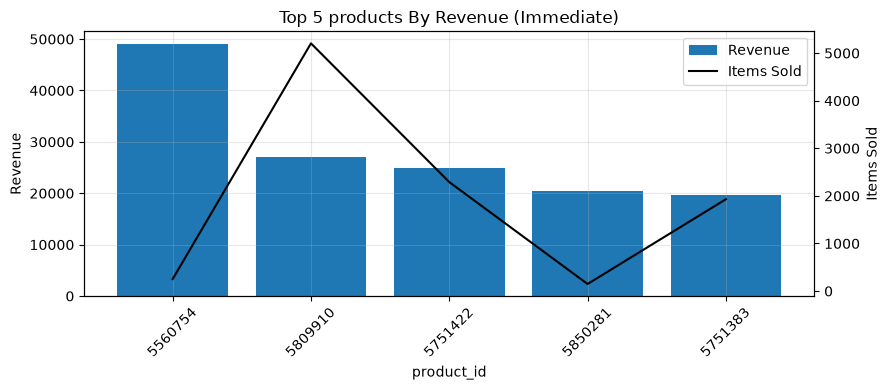

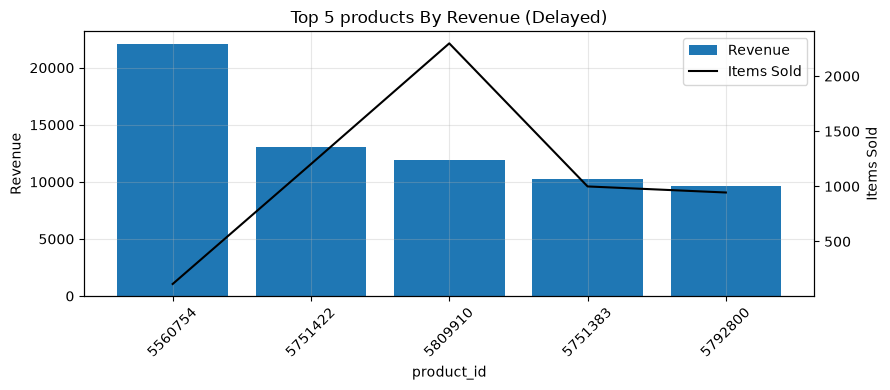

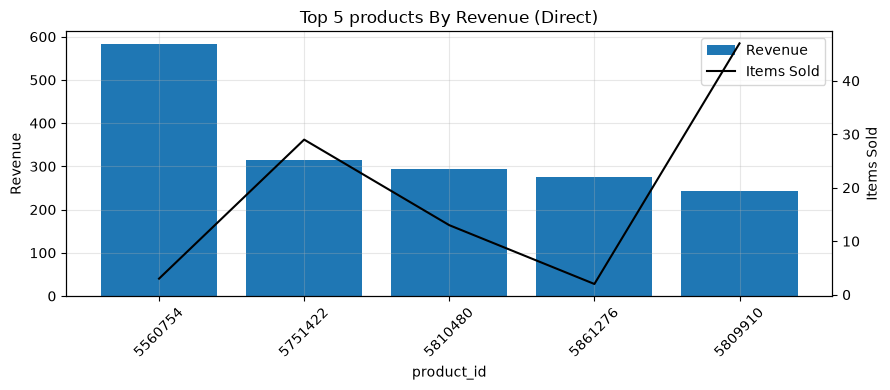

In [64]:
# Three dual-axis charts: Revenue (bars) + Items Sold (lines) for top 5 products

for g in p['group'].dropna().unique():
    d = top5_product_rev[top5_product_rev['group']==g].copy()
    d = d.sort_values('revenue',ascending=False)

    x = d['product_id'].astype(str)
    fig,ax1 = plt.subplots(figsize=(9,4))

    ax1.bar(x,d['revenue'],label='Revenue')
    ax1.set_xlabel('product_id')
    ax1.set_ylabel('Revenue')
    ax1.tick_params(axis='x',rotation=45)
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(x,d['items_sold'],marker='',label='Items Sold',color='black')
    ax2.set_ylabel('Items Sold')

    ax1.set_title(f'Top 5 products By Revenue ({g})')

    h1,l1 = ax1.get_legend_handles_labels()
    h2,l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2,l1+l2,loc='upper right')

    plt.tight_layout()
    plt.show()



---
## End of Analysis

This notebook produced **46 visualizations** covering:
- Funnel analysis (nested & non-nested)
- Three-path purchase classification
- Monthly, weekly, hourly temporal patterns
- New vs. returning customer dynamics
- Category & product deep-dives
